<table>
    <tr>
        <td>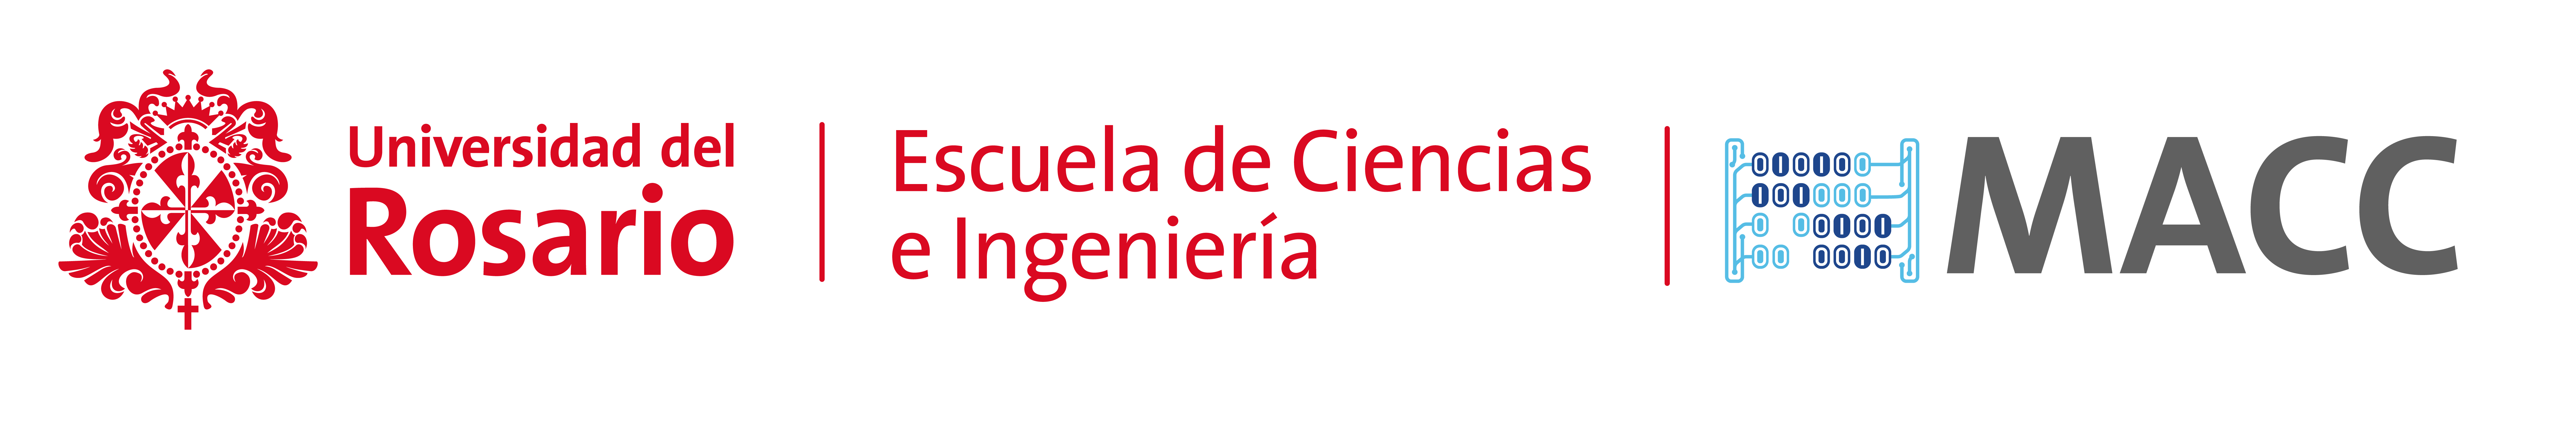</td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;text-align:center">   Árboles de decisión       </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina </p></tp>
            <tp><p style="font-size:80%;text-align:center">Maestría MACC 2025-2</p></tp>
            <tp><p style="font-size:80%;text-align:center">Prof. Luis E. Seijas</p></tp>
        </td>
    </tr>
</table>

## Descripción del Notebook

Este notebook demuestra los conceptos clave de los árboles de decisión utilizando la biblioteca Scikit-Learn en Python. A lo largo de este cuaderno, se explorarán los siguientes temas:

1.  **Árboles de Clasificación:** Se construirán árboles para tareas de clasificación, comparando los criterios de división de **Gini** y **Entropía**.
2.  **Sobreajuste (Overfitting):** Se ilustrará cómo los árboles de decisión pueden crecer demasiado y ajustarse en exceso a los datos de entrenamiento, perdiendo capacidad de generalización.
3.  **Pre-Poda (Pre-pruning):** Se aplicarán técnicas para controlar la complejidad del árbol durante su construcción (ej. `max_depth`, `min_samples_leaf`) y así evitar el sobreajuste.
4.  **Post-Poda (Post-pruning):** Se utilizará la Poda de Complejidad de Costo Mínimo (Minimal Cost-Complexity Pruning) para simplificar un árbol ya entrenado y mejorar su rendimiento en datos no vistos.
5.  **Árboles de Regresión:** Se extenderá el concepto a problemas de regresión, donde el criterio de división se basa en la reducción de la **Varianza** o el Error Cuadrático Medio (MSE).

In [1]:
# Librerias 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, mean_squared_error

In [2]:
# --- Configuración General ---
# Para que los gráficos sean más grandes y legibles
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16

### 1. Árboles de Clasificación: Gini vs. Entropía

Los árboles de decisión para clasificación dividen el espacio de características en regiones, asignando una clase a cada región. Para encontrar las mejores divisiones, se utilizan criterios que miden la "pureza" de los nodos resultantes. Los dos criterios más comunes son la **Impureza de Gini** y la **Ganancia de Información (basada en Entropía)**.

---

#### Criterio de Impureza Gini

La impureza de Gini mide la probabilidad de clasificar incorrectamente un elemento elegido al azar si se etiquetara aleatoriamente según la distribución de clases en el nodo.

**Fórmula:**
Para un nodo dado, la impureza de Gini se calcula como:
$$
Gini = 1 - \sum_{i=1}^{C} (p_i)^2
$$
donde $C$ es el número de clases y $p_i$ es la proporción de muestras de la clase $i$ en el nodo.

*   Un valor de Gini de **0** indica que el nodo es **puro** (todas las muestras pertenecen a la misma clase).
*   Un valor máximo (0.5 para 2 clases) indica una distribución uniforme de clases, es decir, máxima impureza.

El algoritmo busca la división que produce la mayor **reducción en la impureza de Gini**, calculada como un promedio ponderado de la impureza de los nodos hijos.

---

#### Criterio de Ganancia de Información (Entropía)

La entropía es un concepto de la teoría de la información que mide el desorden o la incertidumbre en un conjunto de datos.

**Fórmula de Entropía:**
$$
H(S) = - \sum_{i=1}^{C} p_i \log_2(p_i)
$$
donde $p_i$ es la proporción de muestras de la clase $i$.

*   Una entropía de **0** indica un nodo **puro**.
*   Una entropía máxima indica máxima incertidumbre.

El objetivo es maximizar la **Ganancia de Información (Information Gain)**, que es la reducción de la entropía lograda después de una división:
$$
IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)
$$
donde $H(S)$ es la entropía del nodo padre y el segundo término es la entropía promedio ponderada de los nodos hijos.

---
#### ¿Cuál es la diferencia en la práctica?

*   **Costo Computacional:** El cálculo de Gini es ligeramente más rápido ya que no implica cálculos logarítmicos, que son más costosos computacionalmente que la operación de elevar al cuadrado.
*   **Estructura del Árbol:** La entropía tiende a producir árboles un poco más balanceados. Por otro lado, el criterio Gini tiende a aislar la clase más frecuente en una rama pura.
*   **Rendimiento:** En la mayoría de los casos, ambos criterios conducen a árboles muy similares y su impacto en el rendimiento del modelo es mínimo. Por su eficiencia, Gini es el criterio por defecto en Scikit-Learn.

---

#### Dataset a Utilizar: Wine

Para ilustrar estos conceptos, se utilizará el conjunto de datos **Wine**, disponible en Scikit-Learn. Este es un problema de clasificación clásico donde el objetivo es predecir el origen de vinos (tres clases diferentes) a partir de los resultados de un análisis químico que mide 13 atributos continuos, como el nivel de alcohol, la intensidad del color, etc. Es un buen ejemplo para ver cómo los árboles de decisión manejan problemas multiclase.

---
#### Implementación Práctica y Comparación

En la siguiente celda, se implementarán y compararán ambos criterios utilizando `DecisionTreeClassifier` de Scikit-Learn:

1.  **Carga de Datos:** Se utiliza el dataset `wine`, un problema de clasificación multiclase.
2.  **Creación de Modelos:**
    *   Se crea un árbol con `criterion='gini'` (el valor por defecto).
    *   Se crea un segundo árbol con `criterion='entropy'`.
3.  **Entrenamiento y Evaluación:** Ambos modelos se entrenan con los mismos datos de entrenamiento y se evalúa su precisión (`accuracy_score`) en el conjunto de prueba.
4.  **Visualización:** Se utiliza `plot_tree` para visualizar la estructura de ambos árboles. Aunque a menudo producen árboles muy similares, las divisiones específicas pueden variar, especialmente en los niveles superiores del árbol, lo que puede llevar a diferencias en el rendimiento y la interpretabilidad. En la práctica, Gini tiende a ser ligeramente más rápido de calcular y favorece la creación de nodos puros para la clase mayoritaria, mientras que la entropía puede producir árboles un poco más balanceados.

Precisión del árbol con Gini: 0.9630
Precisión del árbol con Entropía: 0.8519


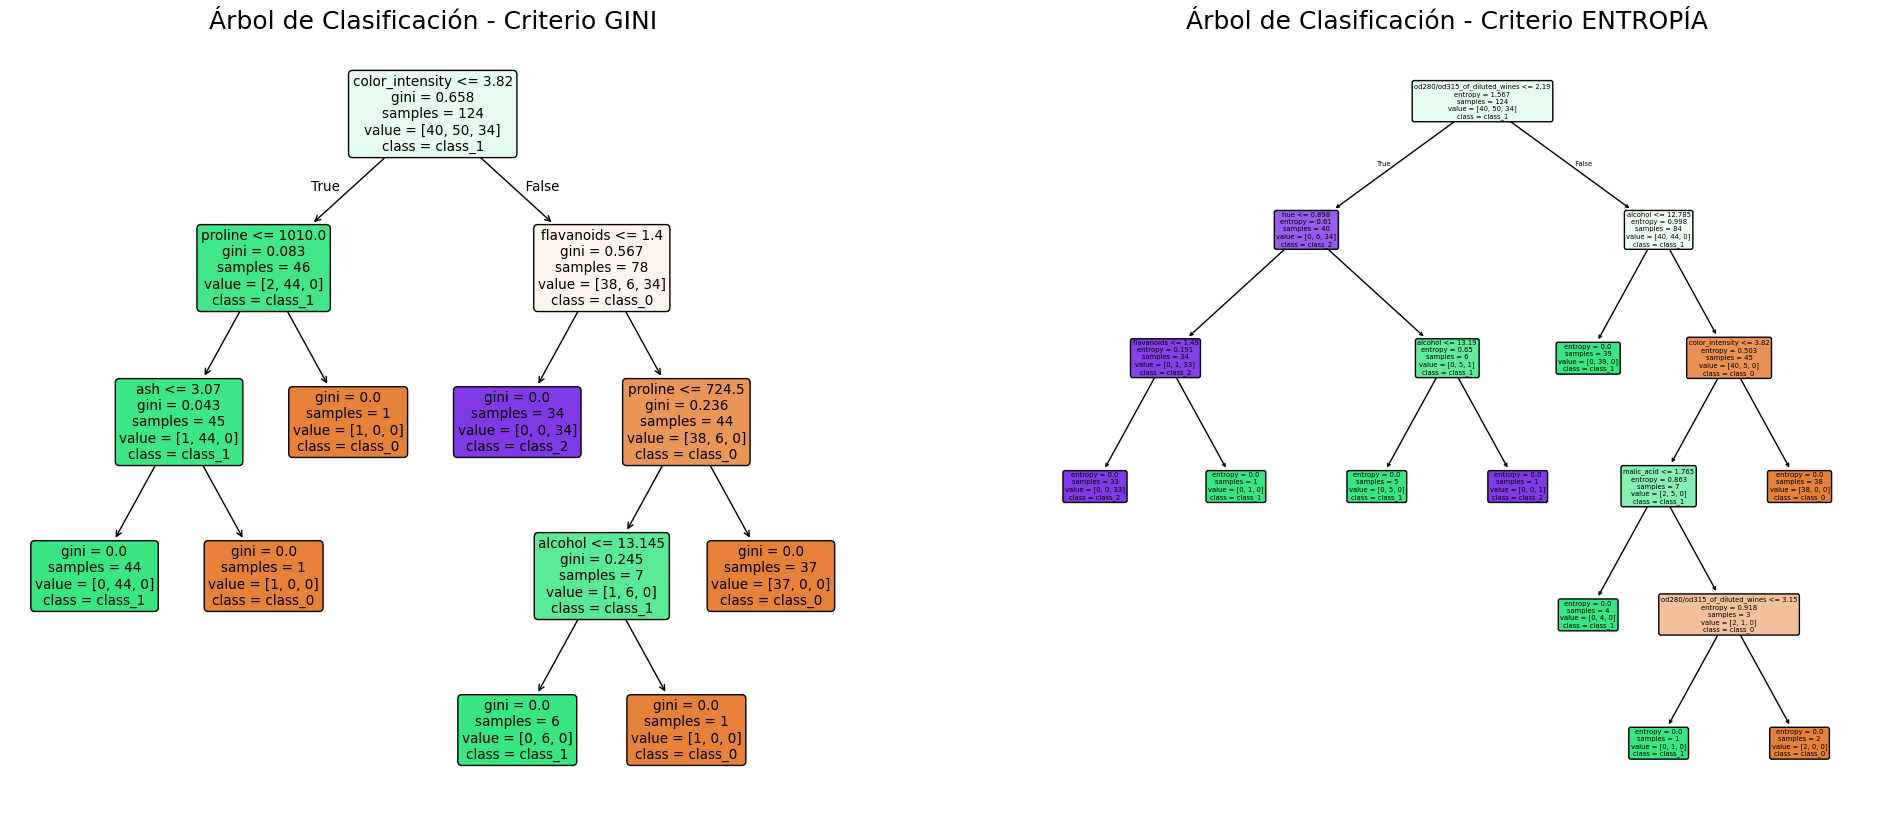

In [3]:
# Cargar el dataset de clasificación
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1a. Entrenar un árbol con el criterio Gini (opción por defecto)
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)
acc_gini = accuracy_score(y_test, clf_gini.predict(X_test))
print(f"Precisión del árbol con Gini: {acc_gini:.4f}")

# 1b. Entrenar un árbol con el criterio Entropía (Ganancia de Información)
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)
acc_entropy = accuracy_score(y_test, clf_entropy.predict(X_test))
print(f"Precisión del árbol con Entropía: {acc_entropy:.4f}")

# Visualizar ambos árboles para compararlos
plt.figure(figsize=(24, 10))
plt.subplot(1, 2, 1)
plot_tree(clf_gini, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, rounded=True)
plt.title("Árbol de Clasificación - Criterio GINI")

plt.subplot(1, 2, 2)
plot_tree(clf_entropy, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, rounded=True)
plt.title("Árbol de Clasificación - Criterio ENTROPÍA")
plt.show()

### 2. Sobreajuste (Overfitting) en Árboles de Decisión

El sobreajuste es uno de los problemas más comunes en el aprendizaje automático. Ocurre cuando un modelo aprende los datos de entrenamiento "demasiado bien", capturando no solo los patrones subyacentes, sino también el ruido y las fluctuaciones aleatorias específicas de ese conjunto de datos. Como resultado, el modelo funciona perfectamente con los datos que ya ha visto, pero pierde su capacidad de **generalización**, es decir, de hacer predicciones precisas sobre datos nuevos y no vistos.

Los árboles de decisión son particularmente propensos al sobreajuste. Si no se les impone ninguna restricción, seguirán creciendo y creando nuevas divisiones hasta que cada nodo terminal (hoja) sea completamente puro, lo que a menudo significa que cada hoja contiene un único o muy pocos ejemplos del conjunto de entrenamiento. Esto da como resultado un árbol extremadamente complejo y profundo que ha "memorizado" los datos de entrenamiento en lugar de aprender las reglas generales que gobiernan la distribución de los datos.

El síntoma clásico del sobreajuste es una **gran diferencia** entre el rendimiento del modelo en el conjunto de entrenamiento y en el conjunto de prueba:
*   **Precisión en Entrenamiento:** Muy alta, a menudo cercana o igual al 100%.
*   **Precisión en Prueba:** Significativamente más baja.

En la siguiente celda, se demostrará este fenómeno:
1.  Se entrenará un `DecisionTreeClassifier` sin ninguna restricción de crecimiento (`max_depth`, `min_samples_leaf`, etc.).
2.  Se medirá y comparará la precisión en los datos de entrenamiento y de prueba.
3.  Se visualizará el árbol resultante para observar su complejidad.

Se espera ver una precisión perfecta en el entrenamiento pero una precisión mucho menor en la prueba, lo que confirma que el modelo está sobreajustado.

Profundidad del árbol sobreajustado: 4
Precisión en Entrenamiento (sobreajuste): 1.0000
Precisión en Prueba (sobreajuste): 0.9630
Observa la gran diferencia de precisión. ¡Esto es sobreajuste!


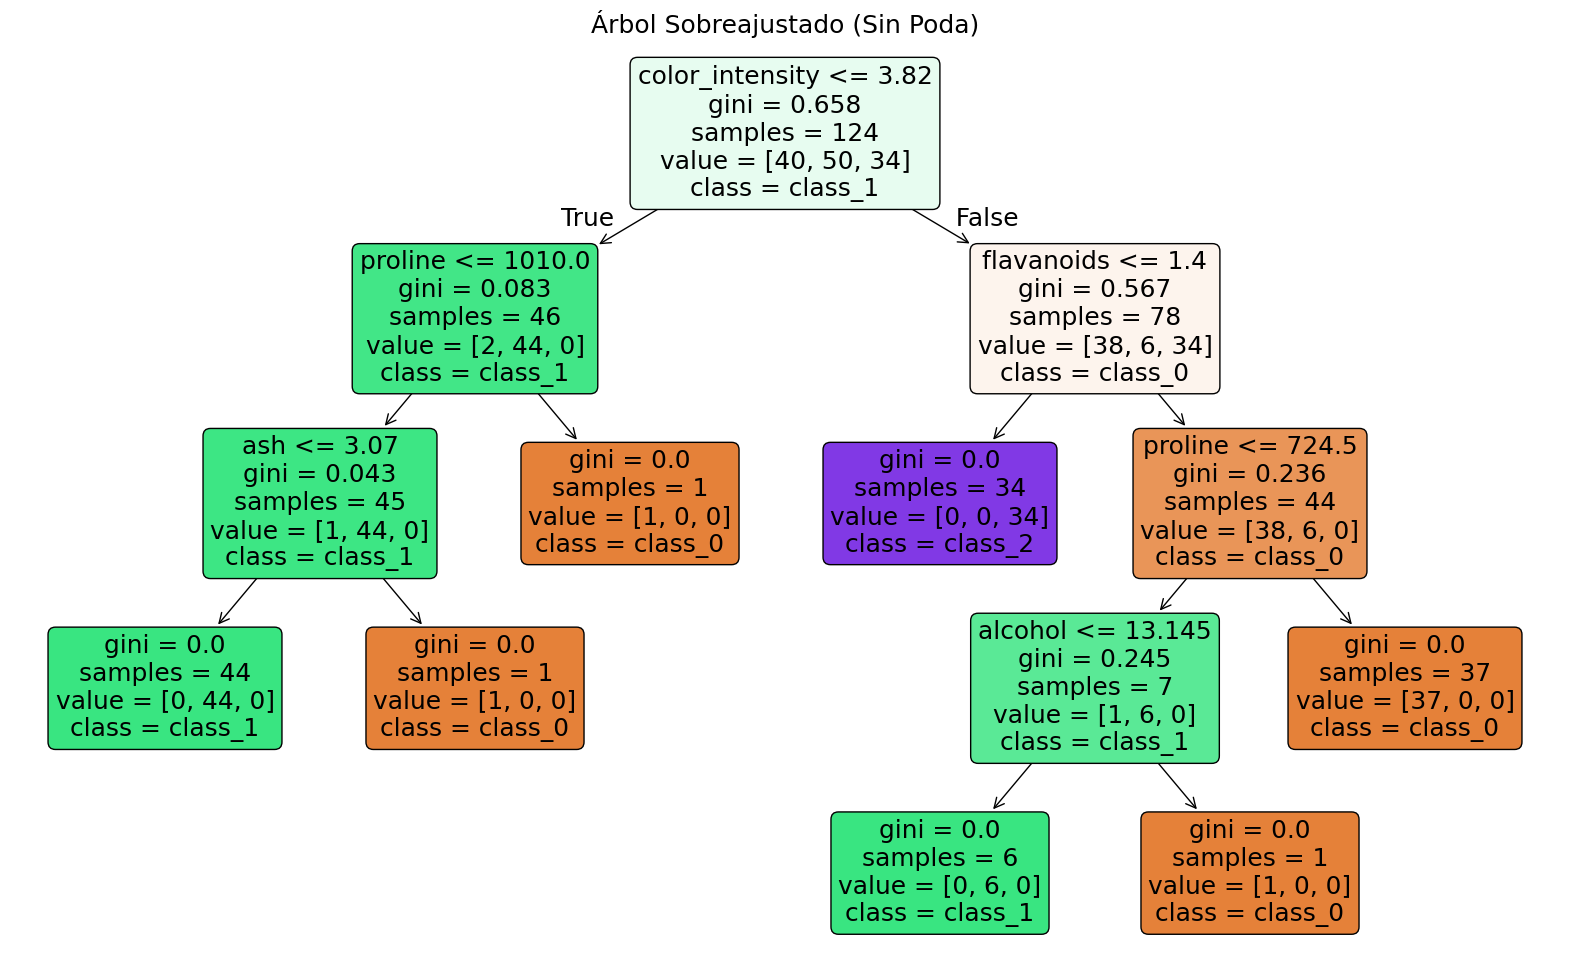

In [4]:
# Entrenamos un árbol sin ninguna restricción para que crezca al máximo
# Esto lo hará memorizar los datos de entrenamiento
clf_overfit = DecisionTreeClassifier(random_state=42)
clf_overfit.fit(X_train, y_train)

# Medimos la precisión en los datos de entrenamiento y de prueba
acc_train = accuracy_score(y_train, clf_overfit.predict(X_train))
acc_test = accuracy_score(y_test, clf_overfit.predict(X_test))

print(f"Profundidad del árbol sobreajustado: {clf_overfit.get_depth()}")
print(f"Precisión en Entrenamiento (sobreajuste): {acc_train:.4f}")
print(f"Precisión en Prueba (sobreajuste): {acc_test:.4f}")
print("Observa la gran diferencia de precisión. ¡Esto es sobreajuste!")

# Visualizar el árbol sobreajustado y complejo
plt.figure()
plot_tree(clf_overfit, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, rounded=True)
plt.title("Árbol Sobreajustado (Sin Poda)")
plt.show()

### 3. Pre-Poda (Pre-pruning) para Controlar el Sobreajuste

Para combatir el sobreajuste, se pueden emplear estrategias de **poda (pruning)**, que consisten en simplificar el árbol de decisión. La **Pre-Poda** (o poda temprana) es una de estas estrategias, y consiste en detener el crecimiento del árbol *antes* de que se ajuste perfectamente a los datos de entrenamiento.

Esto se logra estableciendo criterios de parada durante la fase de construcción del árbol. En lugar de dejar que el árbol se expanda hasta que cada hoja sea pura, se le imponen restricciones para que deje de dividirse si no se cumplen ciertas condiciones. El objetivo es crear un modelo más simple y, por lo tanto, con mejor capacidad de generalización.

En Scikit-Learn, la pre-poda se implementa a través de varios hiperparámetros en el constructor `DecisionTreeClassifier`. Los más importantes son:

*   `max_depth`: Define la profundidad máxima que puede alcanzar el árbol. Limitar la profundidad es una de las formas más directas y efectivas de controlar la complejidad del modelo. Un árbol con `max_depth=3` solo puede hacer, como máximo, tres niveles de preguntas (divisiones) para llegar a una clasificación.

*   `min_samples_split`: Especifica el número mínimo de muestras que un nodo debe tener para poder ser dividido. Si un nodo tiene menos muestras que este umbral, no se dividirá y se convertirá en una hoja, incluso si no es puro.

*   `min_samples_leaf`: Indica el número mínimo de muestras que deben existir en un nodo hoja. Una división solo se considerará válida si los dos nodos hijos resultantes tienen, cada uno, al menos `min_samples_leaf` muestras. Esto ayuda a evitar que se creen hojas con muy pocas muestras, que son un síntoma claro de que el modelo está aprendiendo ruido.

*   `max_leaf_nodes`: Limita el número total de nodos hoja (terminales) en el árbol. El árbol crecerá de manera que se maximice la reducción de impureza, pero respetando este límite.

Al ajustar estos hiperparámetros, se busca un equilibrio: un árbol que no sea ni tan simple que no pueda capturar los patrones de los datos (alto sesgo), ni tan complejo que se ajuste al ruido (alta varianza).

En la siguiente celda, se aplicará la pre-poda estableciendo `max_depth` y `min_samples_leaf` para crear un árbol más robusto y comparar su rendimiento con el del modelo sobreajustado.

--- Analizando el efecto de max_depth ---
max_depth =        2 | Precisión Entrenamiento = 0.9435 | Precisión Prueba = 0.8704
max_depth =        3 | Precisión Entrenamiento = 0.9919 | Precisión Prueba = 0.9630
max_depth =        4 | Precisión Entrenamiento = 1.0000 | Precisión Prueba = 0.9630
max_depth =        5 | Precisión Entrenamiento = 1.0000 | Precisión Prueba = 0.9630
max_depth =       10 | Precisión Entrenamiento = 1.0000 | Precisión Prueba = 0.9630
max_depth = Infinito | Precisión Entrenamiento = 1.0000 | Precisión Prueba = 0.9630

--- Analizando el efecto de min_samples_leaf ---
min_samples_leaf =  1 | Precisión Entrenamiento = 1.0000 | Precisión Prueba = 0.9630
min_samples_leaf =  5 | Precisión Entrenamiento = 0.9758 | Precisión Prueba = 0.9444
min_samples_leaf = 10 | Precisión Entrenamiento = 0.9516 | Precisión Prueba = 0.9444
min_samples_leaf = 15 | Precisión Entrenamiento = 0.9355 | Precisión Prueba = 0.8519
min_samples_leaf = 20 | Precisión Entrenamiento = 0.9355 | Preci

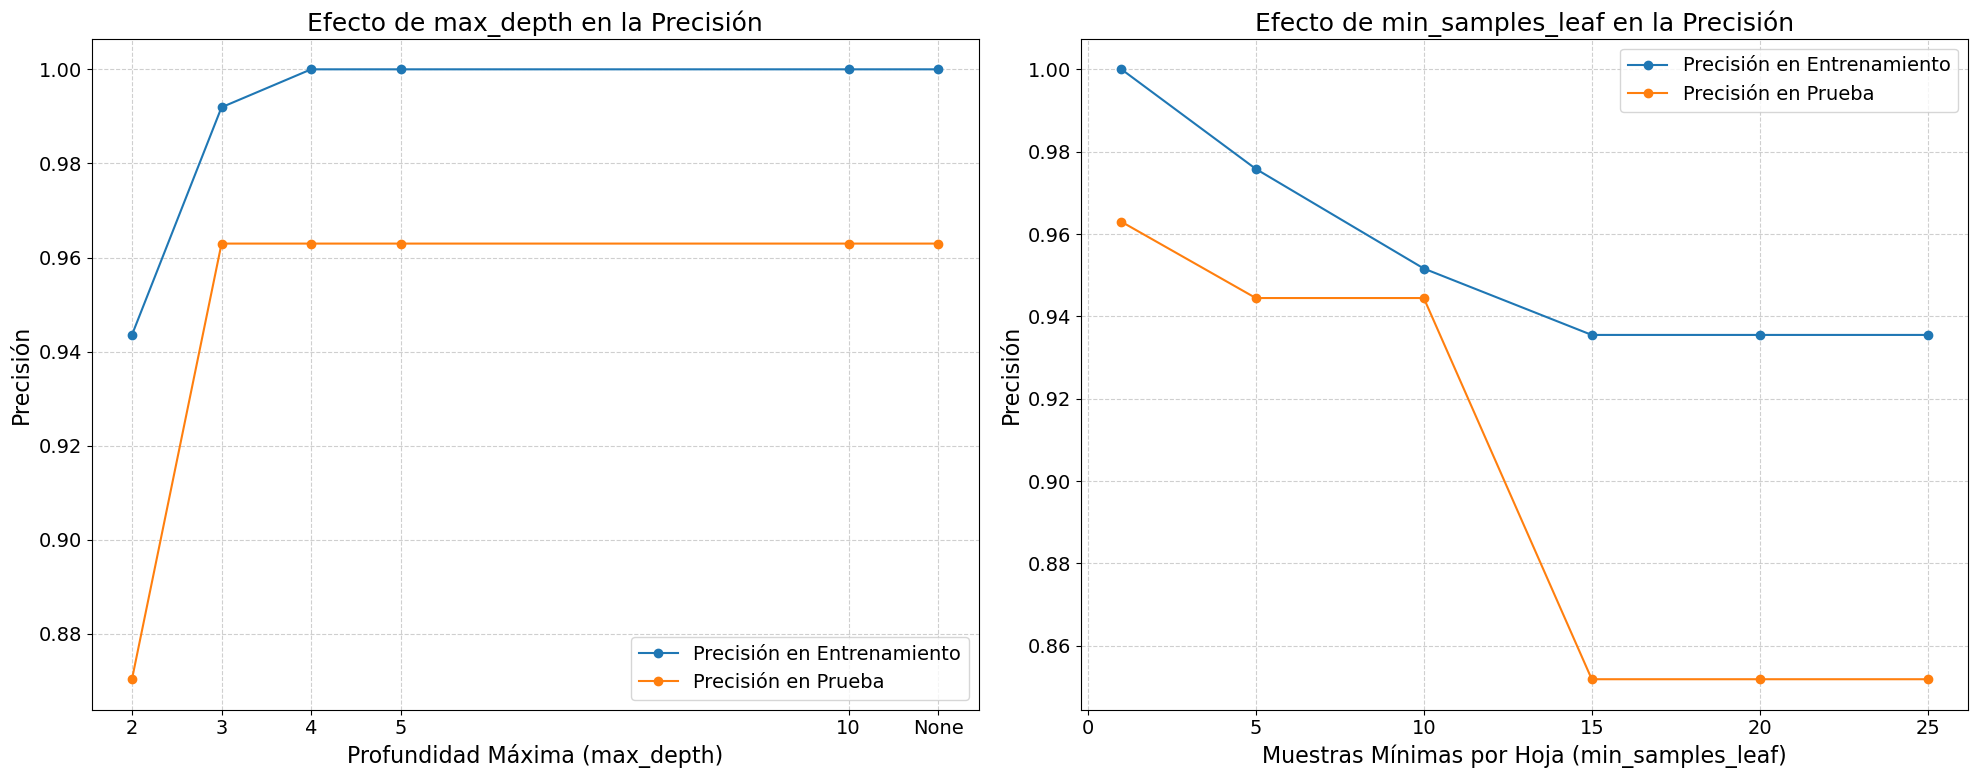


--- Comparación de Rendimiento: Podado vs. Sobreajustado ---
Árbol Podado (max_depth=3):
  Precisión Entrenamiento = 0.9919
  Precisión Prueba = 0.9630

Árbol Sobreajustado (sin límite de profundidad):
  Precisión Entrenamiento = 1.0000
  Precisión Prueba = 0.9630


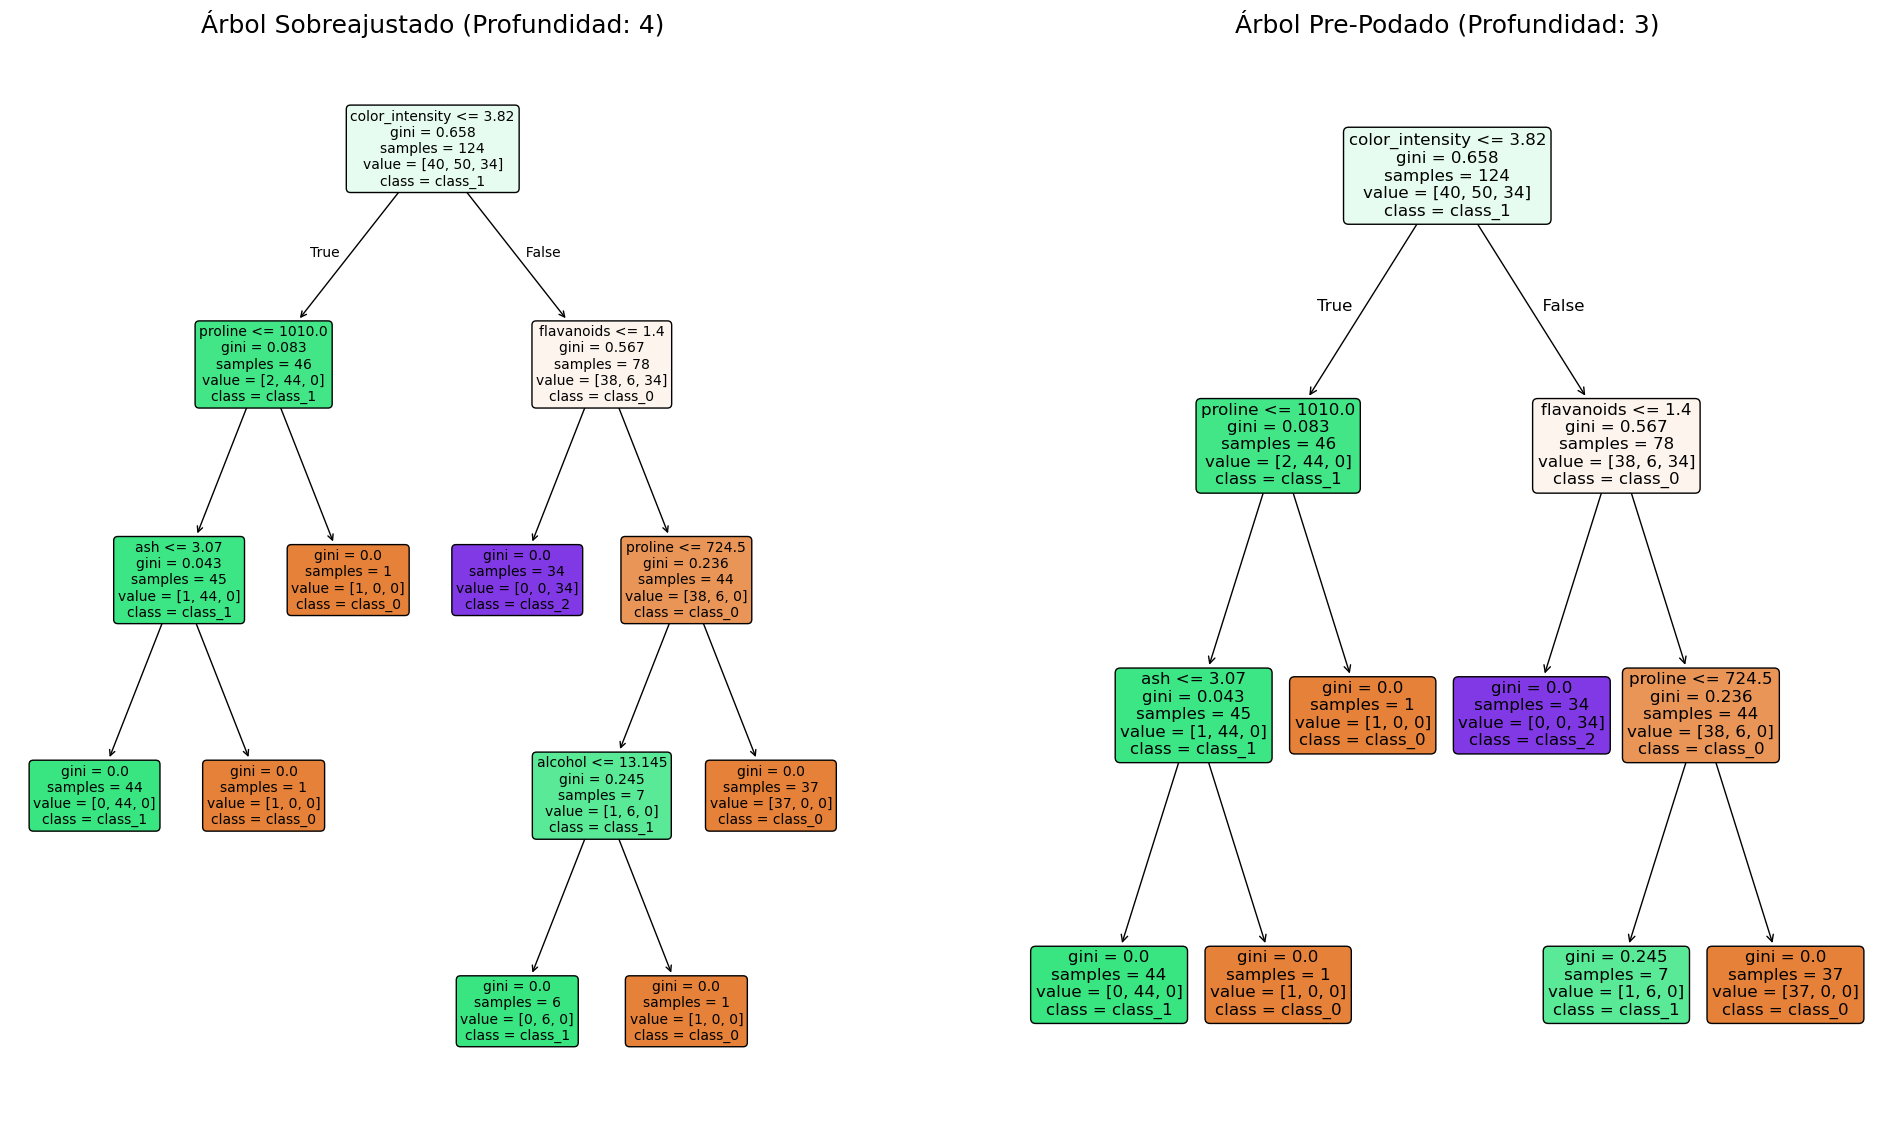

In [5]:
# --- Exploración de Hiperparámetros de Pre-Poda ---

# Se explorará el efecto de dos hiperparámetros clave: max_depth y min_samples_leaf.
# Para ello, se entrenarán varios modelos con diferentes valores para estos parámetros
# y se graficará cómo cambia la precisión en los conjuntos de entrenamiento y prueba.

# 1. Explorar el efecto de `max_depth`
# Se probarán diferentes profundidades, incluyendo 'None' que representa un árbol sin límite de profundidad.
max_depths = [2, 3, 4, 5, 10, None] 
train_accuracies_depth = []
test_accuracies_depth = []

print("--- Analizando el efecto de max_depth ---")
for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    train_accuracies_depth.append(train_acc)
    test_accuracies_depth.append(test_acc)
    
    depth_str = "Infinito" if depth is None else depth
    print(f"max_depth = {depth_str:8} | Precisión Entrenamiento = {train_acc:.4f} | Precisión Prueba = {test_acc:.4f}")

# 2. Explorar el efecto de `min_samples_leaf`
# Se probarán diferentes valores para el mínimo de muestras por hoja. El valor 1 equivale a no tener esta restricción.
min_samples_leafs = [1, 5, 10, 15, 20, 25]
train_accuracies_leaf = []
test_accuracies_leaf = []

print("\n--- Analizando el efecto de min_samples_leaf ---")
for min_leaf in min_samples_leafs:
    clf = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    clf.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    train_accuracies_leaf.append(train_acc)
    test_accuracies_leaf.append(test_acc)
    
    print(f"min_samples_leaf = {min_leaf:2} | Precisión Entrenamiento = {train_acc:.4f} | Precisión Prueba = {test_acc:.4f}")

# --- Visualización de Resultados ---
plt.figure(figsize=(20, 8))

# Gráfico para max_depth
plt.subplot(1, 2, 1)
# Usamos un truco para graficar 'None' como un valor numérico mayor en el eje x
x_axis_depth = [d if d is not None else max(d for d in max_depths if d is not None) + 1 for d in max_depths]
plt.plot(x_axis_depth, train_accuracies_depth, 'o-', label='Precisión en Entrenamiento')
plt.plot(x_axis_depth, test_accuracies_depth, 'o-', label='Precisión en Prueba')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Precisión')
plt.title('Efecto de max_depth en la Precisión')
plt.xticks(ticks=x_axis_depth, labels=[str(d) if d is not None else 'None' for d in max_depths])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico para min_samples_leaf
plt.subplot(1, 2, 2)
plt.plot(min_samples_leafs, train_accuracies_leaf, 'o-', label='Precisión en Entrenamiento')
plt.plot(min_samples_leafs, test_accuracies_leaf, 'o-', label='Precisión en Prueba')
plt.xlabel('Muestras Mínimas por Hoja (min_samples_leaf)')
plt.ylabel('Precisión')
plt.title('Efecto de min_samples_leaf en la Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- Visualización de un Árbol Pre-Podado vs. Sobreajustado ---

# Basado en los gráficos, un buen candidato para un árbol podado es max_depth=3.
# Tiene una alta precisión en prueba sin alcanzar el 100% en entrenamiento, lo que sugiere una buena generalización.
clf_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_pruned.fit(X_train, y_train)

print("\n--- Comparación de Rendimiento: Podado vs. Sobreajustado ---")
acc_train_pruned = accuracy_score(y_train, clf_pruned.predict(X_train))
acc_test_pruned = accuracy_score(y_test, clf_pruned.predict(X_test))

print(f"Árbol Podado (max_depth=3):")
print(f"  Precisión Entrenamiento = {acc_train_pruned:.4f}")
print(f"  Precisión Prueba = {acc_test_pruned:.4f}")

# Los valores acc_train y acc_test fueron calculados en la celda 7 para el árbol sobreajustado
print(f"\nÁrbol Sobreajustado (sin límite de profundidad):")
print(f"  Precisión Entrenamiento = {acc_train:.4f}")
print(f"  Precisión Prueba = {acc_test:.4f}")

# Visualizar el árbol sobreajustado (ya entrenado en la celda 7) y el árbol podado
plt.figure(figsize=(24, 14))

# Árbol Sobreajustado
plt.subplot(1, 2, 1)
plot_tree(clf_overfit, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, rounded=True, fontsize=10)
plt.title(f"Árbol Sobreajustado (Profundidad: {clf_overfit.get_depth()})")

# Árbol Pre-Podado
plt.subplot(1, 2, 2)
plot_tree(clf_pruned, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, rounded=True, fontsize=12)
plt.title(f"Árbol Pre-Podado (Profundidad: {clf_pruned.get_depth()})")

plt.show()

### 4. Post-Poda (Post-pruning) con Poda de Complejidad de Costo Mínimo

A diferencia de la pre-poda, que detiene el crecimiento del árbol, la **Post-Poda** (o simplemente poda) consiste en construir primero un árbol completo y complejo (generalmente sobreajustado) y luego "podarlo" hacia atrás, eliminando las ramas que aportan poco poder predictivo. El objetivo es simplificar el modelo para mejorar su capacidad de generalización.

Scikit-Learn implementa una estrategia de post-poda conocida como **Poda de Complejidad de Costo Mínimo (Minimal Cost-Complexity Pruning)**. Esta técnica se centra en un hiperparámetro de complejidad llamado `ccp_alpha`.

---
#### ¿Cómo funciona la Poda de Complejidad de Costo?

El algoritmo busca el subárbol que minimiza una función de costo-complejidad. Para un árbol dado $T$, esta función se define como:

$$
R_{\alpha}(T) = R(T) + \alpha |\tilde{T}|
$$

Donde:
*   $R(T)$ es la medida de impureza total del árbol (ej. la suma de la impureza Gini de todas las hojas, ponderada por el número de muestras en cada una). Representa qué tan bien el árbol se ajusta a los datos de entrenamiento.
*   $|\tilde{T}|$ es el número de nodos terminales (hojas) en el árbol. Este término penaliza la complejidad del árbol.
*   $\alpha$ (`ccp_alpha`) es el **parámetro de complejidad**. Es un valor no negativo que controla el balance entre el ajuste del árbol y su complejidad.
    *   Si $\alpha = 0$, no hay penalización por complejidad. El costo es simplemente la impureza, por lo que el algoritmo elegirá el árbol más grande y sobreajustado.
    *   A medida que $\alpha$ aumenta, la penalización por tener más hojas se vuelve más significativa. El algoritmo comenzará a preferir árboles más pequeños (con menos hojas) porque, aunque su impureza $R(T)$ sea mayor, el costo total $R_{\alpha}(T)$ será menor.

El proceso funciona de la siguiente manera:

1.  **Entrenar un árbol completo:** Primero, se entrena un árbol de decisión sin restricciones de crecimiento, permitiendo que se sobreajuste a los datos de entrenamiento.

2.  **Calcular la ruta de poda:** El algoritmo no prueba todos los $\alpha$ posibles. En su lugar, calcula una secuencia de valores "efectivos" de $\alpha$. Cada uno de estos valores es el punto exacto en el que podar una nueva rama (el "eslabón más débil") se vuelve óptimo para minimizar la función de costo-complejidad. Esto genera una secuencia de subárboles, desde el más complejo hasta el más simple (solo la raíz).

3.  **Encontrar el `alpha` óptimo:** Para cada valor de `ccp_alpha` en la ruta de poda, se entrena un nuevo árbol. El objetivo es encontrar el valor de `ccp_alpha` que produzca el árbol con el mejor rendimiento en el conjunto de prueba. Este valor representa el equilibrio ideal entre la complejidad del modelo y su capacidad de generalización.

---

En la siguiente celda, se aplicará esta técnica:
1.  Se entrenará un árbol completo.
2.  Se obtendrá la secuencia de valores `ccp_alpha` efectivos utilizando `cost_complexity_pruning_path`.
3.  Se entrenará un árbol para cada `ccp_alpha` y se registrará su precisión en los conjuntos de entrenamiento y prueba.
4.  Se visualizará cómo varía la precisión en función de `ccp_alpha` para encontrar el valor óptimo.
5.  Finalmente, se entrenará y visualizará el árbol post-podado óptimo, comparándolo con el modelo sobreajustado.

--- Analizando el efecto de ccp_alpha ---
ccp_alpha = 0.0000 | Nodos = 7   | Profundidad = 4  | Precisión Prueba = 0.9630
ccp_alpha = 0.0138 | Nodos = 6   | Profundidad = 3  | Precisión Prueba = 0.9630
ccp_alpha = 0.0154 | Nodos = 4   | Profundidad = 3  | Precisión Prueba = 0.9444
ccp_alpha = 0.0698 | Nodos = 3   | Profundidad = 2  | Precisión Prueba = 0.8519


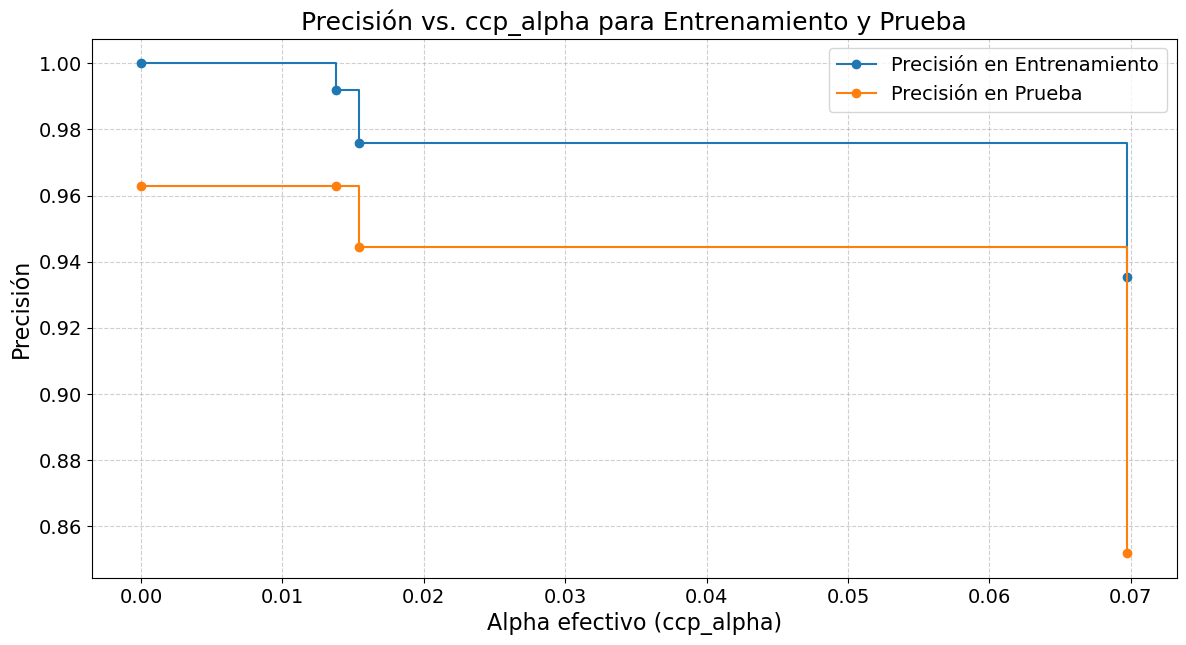


El mejor valor de ccp_alpha encontrado es: 0.0138
Este valor corresponde a una precisión en prueba de: 0.9630

--- Comparación de Rendimiento: Post-Podado vs. Sobreajustado ---
Árbol Post-Podado (ccp_alpha=0.0138):
  Precisión Entrenamiento = 0.9919
  Precisión Prueba = 0.9630

Árbol Sobreajustado (sin poda):
  Precisión Entrenamiento = 1.0000
  Precisión Prueba = 0.9630


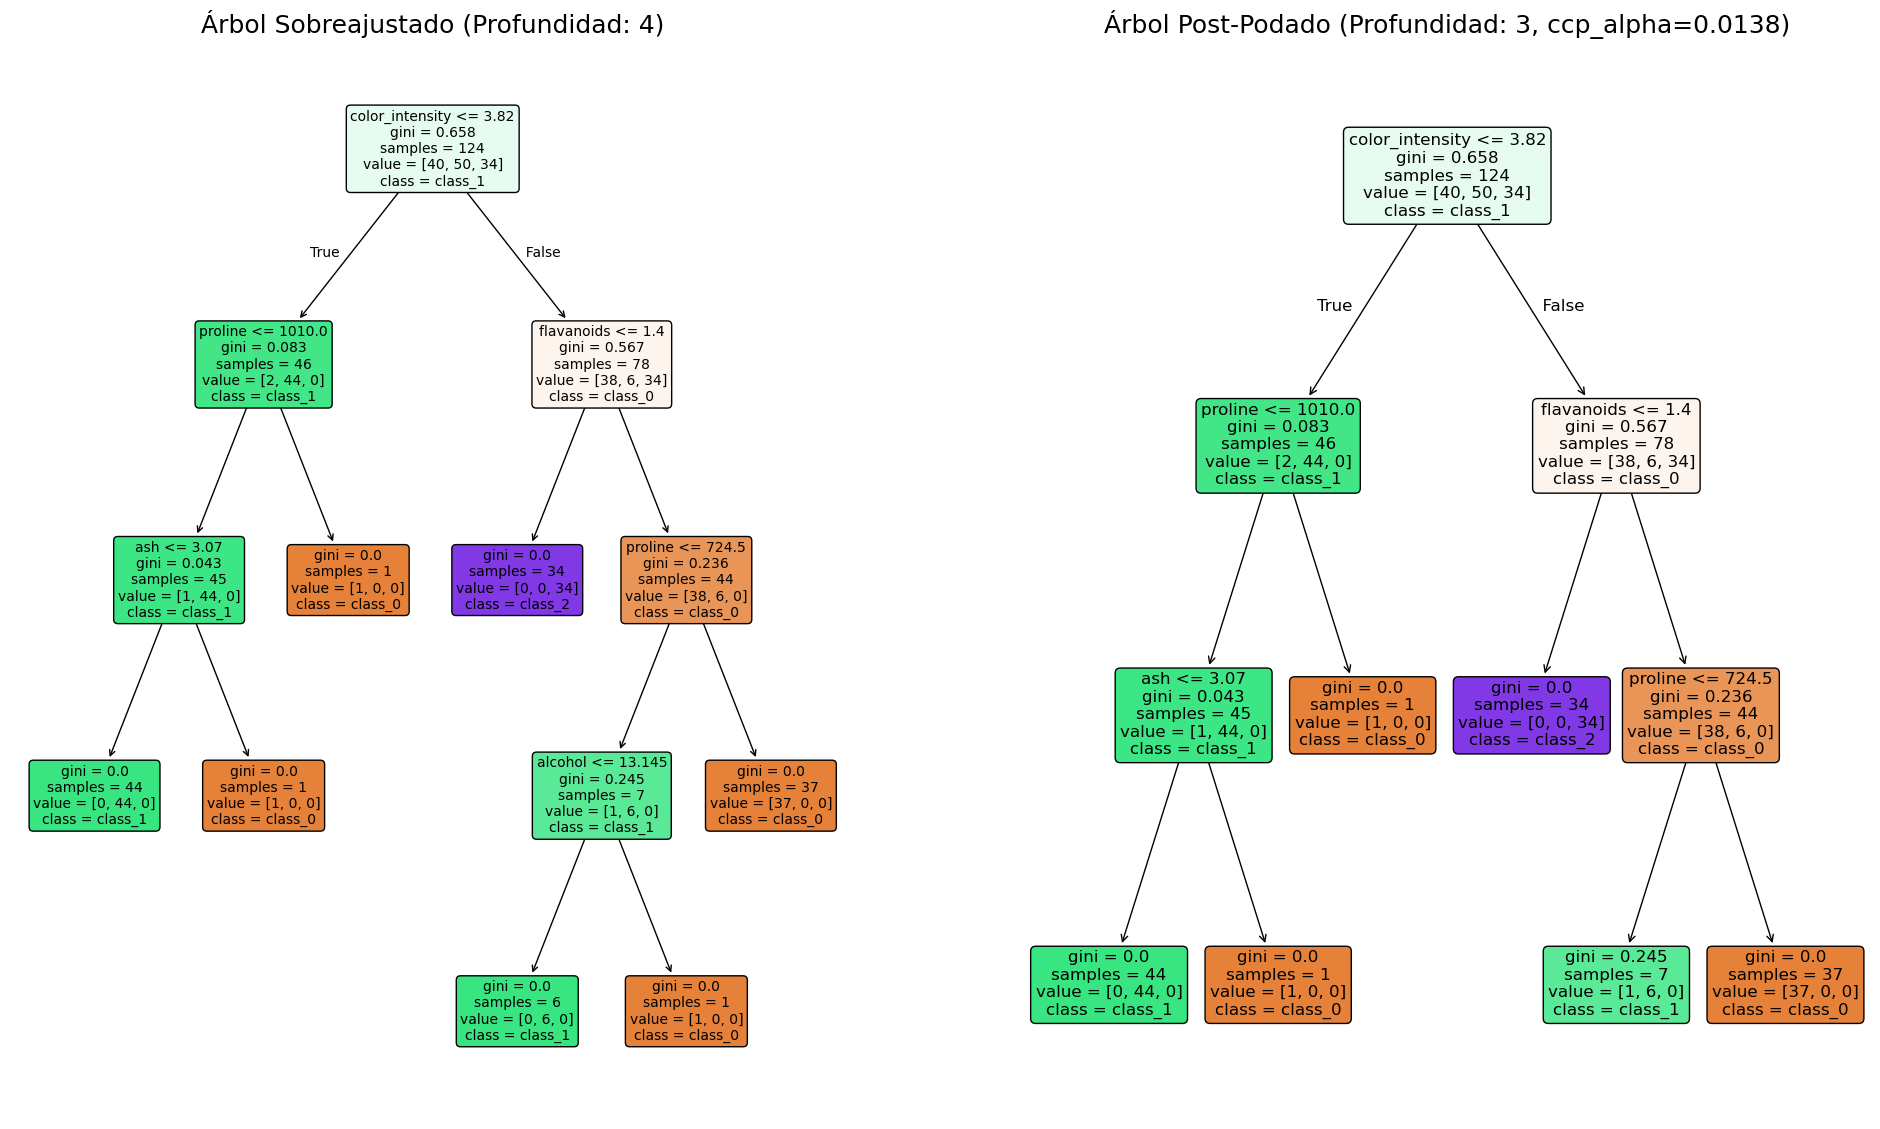

In [6]:
# --- Implementación de Post-Poda con ccp_alpha ---

# 1. Obtener la ruta de poda de complejidad de costo
# Primero, se entrena un árbol sin restricciones para poder calcular los 'alphas' efectivos.
clf_base = DecisionTreeClassifier(random_state=42)
path = clf_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Se elimina el último valor de alpha, que corresponde a un árbol con un solo nodo (la raíz).
ccp_alphas = ccp_alphas[:-1]

# 2. Entrenar un árbol para cada valor de ccp_alpha
clfs = []
train_accs = []
test_accs = []

print("--- Analizando el efecto de ccp_alpha ---")
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    clfs.append(clf)
    
    print(f"ccp_alpha = {ccp_alpha:.4f} | Nodos = {clf.get_n_leaves():<3} | Profundidad = {clf.get_depth():<2} | Precisión Prueba = {test_acc:.4f}")

# 3. Encontrar el alpha óptimo y visualizar la curva de precisión
plt.figure(figsize=(14, 7))
plt.plot(ccp_alphas, train_accs, marker='o', label='Precisión en Entrenamiento', drawstyle="steps-post")
plt.plot(ccp_alphas, test_accs, marker='o', label='Precisión en Prueba', drawstyle="steps-post")
plt.xlabel("Alpha efectivo (ccp_alpha)")
plt.ylabel("Precisión")
plt.title("Precisión vs. ccp_alpha para Entrenamiento y Prueba")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Identificar el mejor clasificador.
# Si varios modelos tienen la misma mejor precisión en prueba, se elige el más simple (mayor alpha).
best_score = np.max(test_accs)
best_alpha_indices = np.where(test_accs == best_score)[0]
best_alpha_index = best_alpha_indices[-1] # Tomar el último índice, que corresponde al mayor alpha

best_ccp_alpha = ccp_alphas[best_alpha_index]
clf_post_pruned = clfs[best_alpha_index]

print(f"\nEl mejor valor de ccp_alpha encontrado es: {best_ccp_alpha:.4f}")
print(f"Este valor corresponde a una precisión en prueba de: {test_accs[best_alpha_index]:.4f}")

# 4. Comparar el árbol post-podado con el árbol sobreajustado
print("\n--- Comparación de Rendimiento: Post-Podado vs. Sobreajustado ---")
print(f"Árbol Post-Podado (ccp_alpha={best_ccp_alpha:.4f}):")
print(f"  Precisión Entrenamiento = {train_accs[best_alpha_index]:.4f}")
print(f"  Precisión Prueba = {test_accs[best_alpha_index]:.4f}")

# Los valores acc_train y acc_test fueron calculados en la celda 7 para el árbol sobreajustado
print(f"\nÁrbol Sobreajustado (sin poda):")
print(f"  Precisión Entrenamiento = {acc_train:.4f}")
print(f"  Precisión Prueba = {acc_test:.4f}")


# Visualizar el árbol sobreajustado (ya entrenado en la celda 7) y el árbol post-podado
plt.figure(figsize=(24, 14))

# Árbol Sobreajustado
plt.subplot(1, 2, 1)
plot_tree(clf_overfit, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, rounded=True, fontsize=10)
plt.title(f"Árbol Sobreajustado (Profundidad: {clf_overfit.get_depth()})")

# Árbol Post-Podado
plt.subplot(1, 2, 2)
plot_tree(clf_post_pruned, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, rounded=True, fontsize=12)
plt.title(f"Árbol Post-Podado (Profundidad: {clf_post_pruned.get_depth()}, ccp_alpha={best_ccp_alpha:.4f})")

plt.show()


### 5. Árboles de Regresión: Reducción de la Varianza (MSE)

Los árboles de decisión no se limitan a problemas de clasificación; también son una herramienta poderosa para tareas de **regresión**, donde el objetivo es predecir un valor continuo en lugar de una etiqueta de clase. El principio fundamental de dividir el espacio de características en regiones rectangulares sigue siendo el mismo, pero el criterio para realizar estas divisiones y la forma de hacer predicciones cambian.

---
#### Criterio de División: Minimizar el Error Cuadrático Medio (MSE)

En lugar de buscar la "pureza" de clase (Gini o Entropía), los árboles de regresión buscan dividir los datos de manera que la **varianza** del objetivo en los nodos hijos sea lo más baja posible. Minimizar la varianza es matemáticamente equivalente a minimizar el **Error Cuadrático Medio (Mean Squared Error - MSE)**.

Para un nodo dado, el MSE se calcula como el promedio de las diferencias al cuadrado entre los valores reales del objetivo ($y_i$) y el valor predicho para ese nodo. La predicción para cualquier muestra que caiga en un nodo es simplemente el **promedio** de los valores del objetivo ($\bar{y}_{node}$) de todas las muestras de entrenamiento en ese nodo.

**Fórmula del MSE en un nodo:**
$$
MSE_{node} = \frac{1}{N_{node}} \sum_{i \in node} (y_i - \bar{y}_{node})^2
$$
donde $N_{node}$ es el número de muestras en el nodo.

El algoritmo de construcción del árbol evalúa cada posible división (en cada característica y en cada umbral) y elige aquella que produce la mayor **reducción del MSE**. La reducción se calcula como la diferencia entre el MSE del nodo padre y el promedio ponderado del MSE de los dos nodos hijos:

$$
\text{Reducción de MSE} = MSE_{padre} - \left( \frac{N_{izq}}{N_{padre}} MSE_{izq} + \frac{N_{der}}{N_{padre}} MSE_{der} \right)
$$

El árbol continúa este proceso de división recursiva hasta que se alcanza un criterio de parada (por ejemplo, `max_depth` o `min_samples_leaf`).

---
#### Predicción y Poda

*   **Predicción:** Para predecir el valor de una nueva muestra, esta recorre el árbol desde la raíz hasta llegar a un nodo hoja. El valor predicho es simplemente el **promedio de los valores del objetivo** de las muestras de entrenamiento que pertenecen a esa hoja.
*   **Poda:** Al igual que los árboles de clasificación, los árboles de regresión son propensos al sobreajuste. Un árbol no podado seguirá dividiéndose hasta que cada hoja contenga muy pocas muestras (o incluso una sola), memorizando los datos de entrenamiento. Por lo tanto, las técnicas de **pre-poda** (`max_depth`, `min_samples_leaf`) y **post-poda** (`ccp_alpha`) son igualmente cruciales para construir modelos de regresión robustos.

---
#### Dataset a Utilizar: Diabetes

Para esta sección, se utilizará el conjunto de datos **Diabetes**, un benchmark clásico para algoritmos de regresión disponible en Scikit-Learn. El objetivo es predecir una medida cuantitativa de la progresión de la enfermedad un año después de la línea base.

*   **Características (Features):** El dataset contiene 10 variables de línea base para cada paciente, que son fisiológicas y normalizadas (media cero, varianza unitaria):
    1.  `age`: Edad en años.
    2.  `sex`: Sexo del paciente.
    3.  `bmi`: Índice de masa corporal (Body Mass Index).
    4.  `bp`: Presión arterial media.
    5.  `s1`, `s2`, `s3`, `s4`, `s5`, `s6`: Seis mediciones de suero sanguíneo (ej. colesterol total, lipoproteínas de baja y alta densidad, etc.).
*   **Objetivo (Target):** Una medida cuantitativa de la progresión de la enfermedad un año después. Es un valor continuo, lo que lo convierte en un problema de regresión.

Este dataset es ideal para demostrar cómo un árbol de regresión particiona el espacio de características para predecir un valor numérico.

---
#### Implementación en Scikit-Learn

*   **Clase:** Se utiliza `sklearn.tree.DecisionTreeRegressor`.
*   **Criterio:** El hiperparámetro `criterion` por defecto es `'squared_error'`, que implementa la minimización del MSE. Otras opciones incluyen `'friedman_mse'` (una versión mejorada para árboles de gradiente) y `'absolute_error'` (que minimiza el Error Absoluto Medio, L1).
*   **Métrica de Evaluación:** Para problemas de regresión, una métrica común es el `mean_squared_error` (MSE), que mide el promedio de los errores al cuadrado. Un valor más bajo indica un mejor ajuste del modelo.

En la siguiente celda, se entrenará un `DecisionTreeRegressor`, se explorará el efecto del hiperparámetro `max_depth` para controlar el sobreajuste, se evaluará su rendimiento con el MSE y se visualizará el árbol resultante para entender cómo se realizan las divisiones y predicciones en un contexto de regresión.

--- Analizando el efecto de max_depth en el Árbol de Regresión ---
max_depth =        2 | MSE Entrenamiento =  3442.46 | MSE Prueba =  3479.64
max_depth =        3 | MSE Entrenamiento =  2918.47 | MSE Prueba =  3616.77
max_depth =        4 | MSE Entrenamiento =  2450.51 | MSE Prueba =  3649.42
max_depth =        5 | MSE Entrenamiento =  1965.72 | MSE Prueba =  3818.07
max_depth =       10 | MSE Entrenamiento =   301.93 | MSE Prueba =  5206.91
max_depth = Infinito | MSE Entrenamiento =     0.00 | MSE Prueba =  5697.79


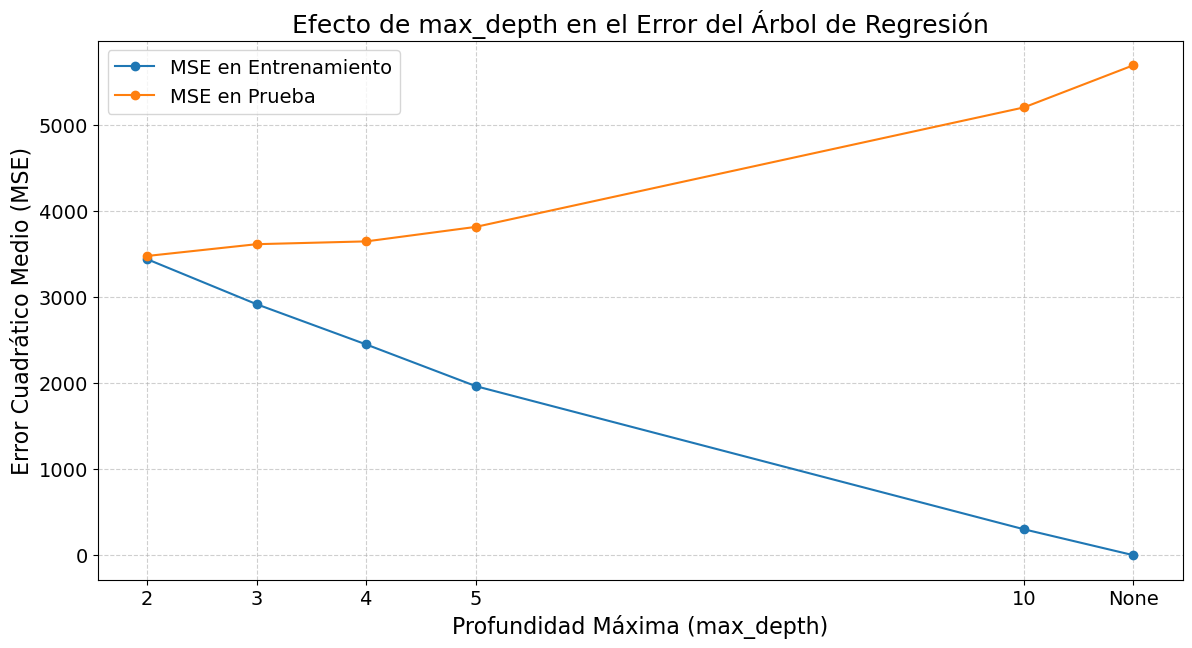


Error Cuadrático Medio (MSE) del Árbol de Regresión Podado (max_depth=3): 3616.77


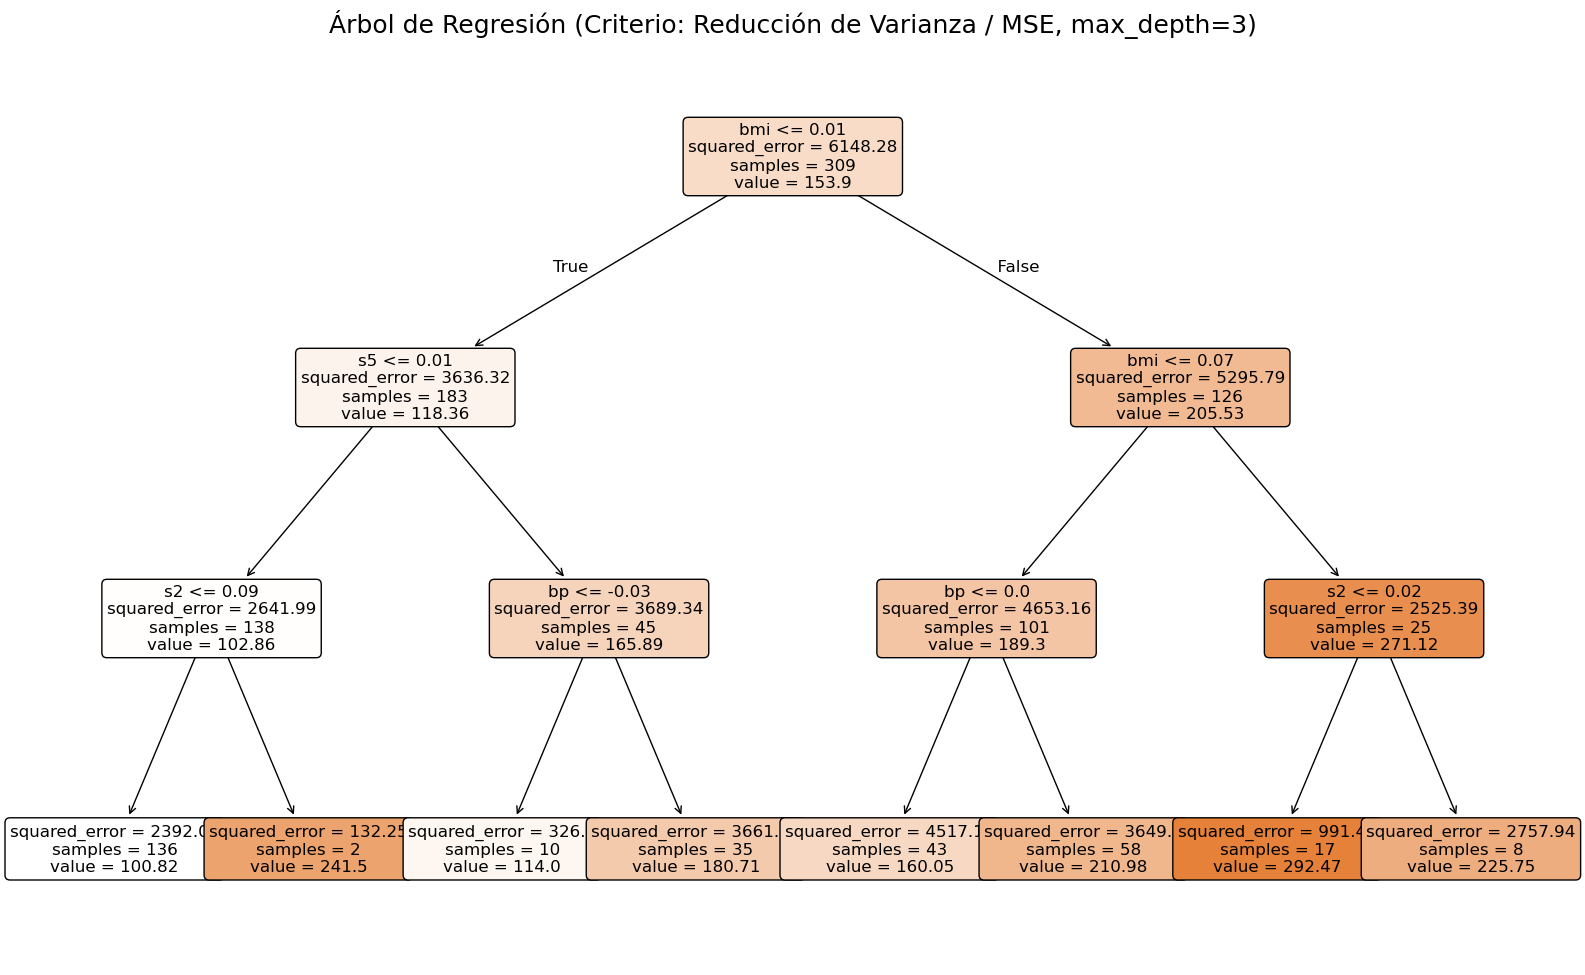

In [7]:
# Cargar el dataset de regresión
diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# --- Exploración del hiperparámetro max_depth para Regresión ---
# Se entrena una serie de árboles con diferente profundidad máxima para ver su efecto en el error.
max_depths_reg = [2, 3, 4, 5, 10, None]
train_mses = []
test_mses = []

print("--- Analizando el efecto de max_depth en el Árbol de Regresión ---")
for depth in max_depths_reg:
    # Se crea y entrena el árbol de regresión con una profundidad específica
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_reg_train, y_reg_train)
    
    # Se calcula el MSE en los datos de entrenamiento y prueba
    train_mse = mean_squared_error(y_reg_train, reg.predict(X_reg_train))
    test_mse = mean_squared_error(y_reg_test, reg.predict(X_reg_test))
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    depth_str = "Infinito" if depth is None else depth
    print(f"max_depth = {depth_str:8} | MSE Entrenamiento = {train_mse:8.2f} | MSE Prueba = {test_mse:8.2f}")

# --- Visualización del efecto de max_depth ---
plt.figure(figsize=(14, 7))
x_axis_depth_reg = [d if d is not None else max(d for d in max_depths_reg if d is not None) + 1 for d in max_depths_reg]
plt.plot(x_axis_depth_reg, train_mses, 'o-', label='MSE en Entrenamiento')
plt.plot(x_axis_depth_reg, test_mses, 'o-', label='MSE en Prueba')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Efecto de max_depth en el Error del Árbol de Regresión')
plt.xticks(ticks=x_axis_depth_reg, labels=[str(d) if d is not None else 'None' for d in max_depths_reg])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Visualización del Árbol de Regresión Óptimo ---
# Basado en el gráfico, una profundidad de 3 o 4 parece un buen compromiso.
# Ofrece un MSE en prueba bajo sin que el MSE de entrenamiento sea cero (lo que indicaría sobreajuste).
# Se elige max_depth=3 para una mejor visualización.
best_depth_reg = 3
reg_tree_pruned = DecisionTreeRegressor(max_depth=best_depth_reg, random_state=42)
reg_tree_pruned.fit(X_reg_train, y_reg_train)

# Predecir y evaluar el error del modelo final
y_pred_reg = reg_tree_pruned.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred_reg)
print(f"\nError Cuadrático Medio (MSE) del Árbol de Regresión Podado (max_depth={best_depth_reg}): {mse:.2f}")

# Visualizar el árbol de regresión
# - 'squared_error' es la Varianza (MSE) del nodo.
# - 'value' es el promedio del objetivo en ese nodo (la predicción de la hoja).
plt.figure(figsize=(20, 12))
plot_tree(reg_tree_pruned, filled=True, feature_names=diabetes.feature_names, rounded=True, precision=2, fontsize=12)
plt.title(f"Árbol de Regresión (Criterio: Reducción de Varianza / MSE, max_depth={best_depth_reg})")
plt.show()


### 6. Árboles para Regresión 📈

Hasta ahora hemos predicho categorías (vino bueno vs. vino malo). Pero, ¿qué pasa si queremos predecir un número continuo, como el precio de la botella o el nivel exacto de pH?

Para esto usamos un **Árbol de Regresión**. La lógica de dividir el espacio iterativamente con preguntas Sí/No es exactamente la misma. Sin embargo, cambian dos cosas fundamentales:
1. **El criterio de corte:** Ya no usamos Gini o Entropía (porque no hay "clases" que purificar). En su lugar, el árbol busca el corte que minimice el **Error Cuadrático Medio (MSE)** o la **Varianza** en los nodos resultantes.
2. **La predicción final:** Cuando un nuevo dato llega a una hoja final, la predicción no es una clase mayoritaria, sino el **promedio matemático** de todos los valores de entrenamiento que cayeron en esa hoja.

Para entender esto visualmente, vamos a crear un conjunto de datos sintético (una onda senoidal con un poco de ruido) y veremos cómo el árbol intenta predecir la línea.

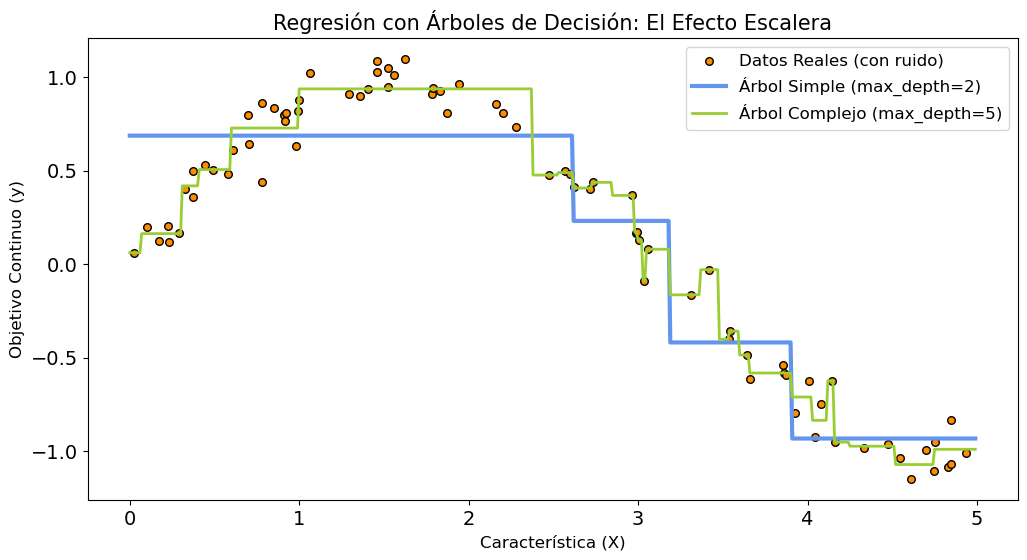

In [8]:
from sklearn.tree import DecisionTreeRegressor

# 1. Generar datos sintéticos (1D) para visualización
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0) # 80 valores aleatorios entre 0 y 5
# La variable objetivo es el seno de X más un poco de ruido gaussiano
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0]) 

# 2. Instanciar y entrenar DOS árboles con diferente profundidad para comparar
tree_reg_simple = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg_complex = DecisionTreeRegressor(max_depth=5, random_state=42)

tree_reg_simple.fit(X_reg, y_reg)
tree_reg_complex.fit(X_reg, y_reg)

# 3. Crear datos de prueba (línea continua) para ver la predicción del modelo
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred_simple = tree_reg_simple.predict(X_test)
y_pred_complex = tree_reg_complex.predict(X_test)

# 4. Visualizar
plt.figure(figsize=(12, 6))
plt.scatter(X_reg, y_reg, s=30, edgecolor="black", c="darkorange", label="Datos Reales (con ruido)")
plt.plot(X_test, y_pred_simple, color="cornflowerblue", label="Árbol Simple (max_depth=2)", linewidth=3)
plt.plot(X_test, y_pred_complex, color="yellowgreen", label="Árbol Complejo (max_depth=5)", linewidth=2)

plt.xlabel("Característica (X)", fontsize=12)
plt.ylabel("Objetivo Continuo (y)", fontsize=12)
plt.title("Regresión con Árboles de Decisión: El Efecto Escalera", fontsize=15)
plt.legend(fontsize=12)
plt.show()

### ¿Qué estamos viendo aquí? 

A diferencia de la regresión lineal que traza una línea recta o curva suave, el Árbol de Regresión predice en **escalones**. 

* **El árbol simple (azul, max_depth=2):** Hizo muy pocos cortes. Divide el eje X en unos pocos segmentos y predice el promedio (una línea plana) para cada segmento. Es un modelo robusto pero que quizás pierde detalles importantes (Subajuste / Underfitting).
* **El árbol complejo (verde, max_depth=5):** Tiene tantos cortes que intenta perseguir casi cada punto naranja individual, capturando el ruido y subiendo/bajando de forma errática. ¡Hemos vuelto a caer en el **Sobreajuste (Overfitting)**!

Un solo árbol es muy sensible. Es muy difícil encontrar la profundidad "perfecta". Por eso, en la vida real, los científicos de datos casi nunca usan un solo árbol de decisión. ¡Usan bosques enteros!

## 7. Ensambles Paralelos y Reducción de Varianza: Random Forest 🌲🌲🌲

Como observamos en la sección anterior, un árbol de decisión individual presenta una limitación teórica fundamental: tiene **baja generalización debido a su alta varianza** (es altamente inestable). Una perturbación mínima en el conjunto de datos de entrenamiento puede resultar en cortes completamente distintos y, por ende, en una estructura topológica del árbol radicalmente diferente.

Para mitigar este problema, pasamos de usar un único estimador a construir un modelo de **Ensamble**. **Random Forest** es uno de los algoritmos de ensamble en paralelo más potentes. Se basa en el paradigma **Bagging (Bootstrap Aggregating)**, pero le añade una capa fundamental de estocasticidad para garantizar la independencia de los estimadores. Su objetivo matemático central es reducir la varianza global del modelo sin incrementar significativamente el sesgo.

El algoritmo fundamenta su robustez y capacidad de generalización en tres pilares técnicos:

1. **Bootstrap (Muestreo con Reemplazo):** En lugar de entrenar un solo árbol, se construyen $B$ árboles independientes (por ejemplo, 100). Cada árbol se entrena con un subconjunto de datos diferente de tamaño $N$, generado extrayendo muestras del dataset original **con reemplazo**. Estadísticamente, esto implica que en cada subconjunto algunas observaciones se repetirán, mientras que aproximadamente el 36.8% de las muestras originales no serán seleccionadas. A estas observaciones excluidas se les conoce como **Out-of-Bag (OOB)** y proporcionan una métrica de validación cruzada gratuita e intrínseca sin necesidad de separar un set de validación.

2. **Random Subspace Method (Descorrelación de Características):** Si aplicáramos Bagging tradicional y el dataset tuviera un predictor dominante, la mayoría de los árboles lo usarían para el corte en su nodo raíz. Esto generaría un bosque de árboles altamente correlacionados, limitando la reducción de la varianza. Random Forest soluciona esto introduciendo inyección de ruido espacial: **en cada intento de división de un nodo**, el algoritmo no evalúa la totalidad de las $p$ características, sino únicamente un subconjunto aleatorio $m$ (típicamente $m \approx \sqrt{p}$ en problemas de clasificación). Esto fuerza a los árboles a explorar diferentes representaciones del espacio latente y garantiza su descorrelación.

3. **Agregación (Aggregating):** Durante la inferencia, una nueva instancia es evaluada por todos los $B$ árboles simultáneamente. La predicción final se obtiene agregando los resultados: mediante la media aritmética de las salidas (para regresión) o mediante votación mayoritaria / promedio de probabilidades (Soft Voting) para clasificación. Según la ley de los grandes números, el promedio de múltiples variables aleatorias descorrelacionadas reduce drásticamente la varianza del error.

El resultado es un modelo que suaviza las fronteras de decisión "escalonadas" del árbol individual, mitigando severamente el *overfitting*. Implementémoslo y visualicemos su frontera de decisión en 2D.

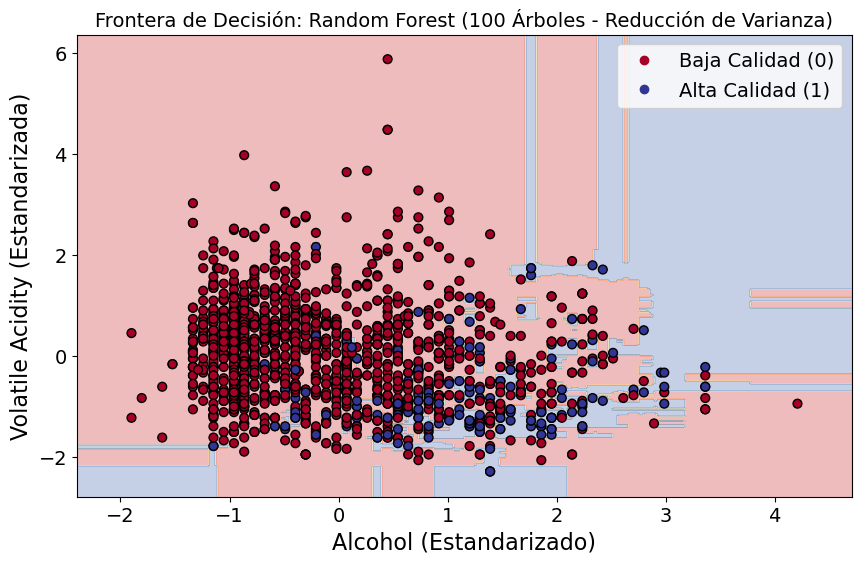

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# ==============================================================================
# 0. PREPARACIÓN DE DATOS (Cargar y escalar X_vis_scaled, y_vis, xx, yy)
# ==============================================================================
# Cargar datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data_clf = pd.read_csv(url, sep=';')

# Extraer 2 variables para visualización
X_vis = wine_data_clf[['alcohol', 'volatile acidity']].values
# Crear etiqueta binaria: Alta calidad (>=7) es 1, resto es 0
y_vis = (wine_data_clf['quality'] >= 7).astype(int) 

# Escalar los datos
scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_vis)

# Crear la malla para el fondo de la gráfica
x_min, x_max = X_vis_scaled[:, 0].min() - 0.5, X_vis_scaled[:, 0].max() + 0.5
y_min, y_max = X_vis_scaled[:, 1].min() - 0.5, X_vis_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# ==============================================================================
# 1. ENTRENAMIENTO DEL MODELO: RANDOM FOREST
# ==============================================================================
# n_estimators=100 define el número 'B' de árboles en el ensamble
# n_jobs=-1 paraleliza el entrenamiento usando todos los núcleos del procesador
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_vis_scaled, y_vis)

# ==============================================================================
# 2. VISUALIZACIÓN DE LA FRONTERA DE DECISIÓN
# ==============================================================================
plt.figure(figsize=(10, 6))

Z_rf = rf_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rf = Z_rf.reshape(xx.shape)

# Pintar las regiones
plt.contourf(xx, yy, Z_rf, alpha=0.3, cmap='RdYlBu')

# Pintar los puntos
scatter = plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis,
                      cmap='RdYlBu', edgecolors='k', s=40)

plt.title('Frontera de Decisión: Random Forest (100 Árboles - Reducción de Varianza)', fontsize=14)
plt.xlabel('Alcohol (Estandarizado)')
plt.ylabel('Volatile Acidity (Estandarizada)')

# Extraer handles y aplicar leyenda
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Baja Calidad (0)', 'Alta Calidad (1)'], loc='upper right')

plt.show()

### 7.1. El Mundo Real: Random Forest con Todas las Variables (Multivariado)

La gráfica 2D nos sirvió para entender cómo el Random Forest suaviza las fronteras de decisión y reduce la varianza. Sin embargo, en un entorno profesional real, casi nunca trabajamos con solo dos variables.

Vamos a liberar todo el potencial del Bosque Aleatorio alimentándolo con las **11 variables fisicoquímicas** del vino simultáneamente. Como ya no podemos visualizar 11 dimensiones, evaluaremos el rendimiento del modelo utilizando las métricas estándar de la industria para clasificación: **El Reporte de Clasificación** y la **Matriz de Confusión**.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS (11 Variables)
# ==============================================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data_rf = pd.read_csv(url, sep=';')

# X_full incluye todas las características físicas y químicas (eliminamos solo el objetivo)
X_full = wine_data_rf.drop('quality', axis=1)
# y_full sigue siendo nuestro objetivo binario: Alta calidad (>=7) es 1, resto 0
y_full = (wine_data_rf['quality'] >= 7).astype(int)

# Partición Estratificada 80/20 (Asegura que la proporción de vinos premium se mantenga)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Entrenando Random Forest con {X_train_full.shape[1]} variables y {X_train_full.shape[0]} muestras...")

# ==============================================================================
# 2. ENTRENAMIENTO DEL MODELO MULTIVARIADO
# ==============================================================================
rf_clf_full = RandomForestClassifier(
    n_estimators=100,      # 100 árboles en el bosque
    random_state=42, 
    n_jobs=-1              # Usar todos los procesadores para entrenar en paralelo
)

rf_clf_full.fit(X_train_full, y_train_full)

# ==============================================================================
# 3. PREDICCIÓN Y REPORTE DE CLASIFICACIÓN
# ==============================================================================
# Ponemos a prueba el modelo con el 20% de datos que nunca ha visto
y_pred_full = rf_clf_full.predict(X_test_full)

print("\n=== Reporte de Validación: Random Forest Multivariado ===")
print(classification_report(y_test_full, y_pred_full, target_names=['Baja Calidad (0)', 'Alta Calidad (1)']))

Entrenando Random Forest con 11 variables y 1279 muestras...

=== Reporte de Validación: Random Forest Multivariado ===
                  precision    recall  f1-score   support

Baja Calidad (0)       0.95      0.99      0.97       277
Alta Calidad (1)       0.93      0.63      0.75        43

        accuracy                           0.94       320
       macro avg       0.94      0.81      0.86       320
    weighted avg       0.94      0.94      0.94       320



### 7.2. Caso Práctico: Predecir el Grado Alcohólico (Regresión Multivariada)

Ya vimos cómo funciona la mecánica interna en 1D. Ahora llevemos el Árbol de Regresión al mundo real. Vamos a utilizar el dataset completo de vinos, pero esta vez cambiaremos nuestro objetivo. 

En lugar de clasificar si un vino es "Bueno" o "Malo", intentaremos **predecir su grado alcohólico exacto** (una variable continua) basándonos en todas sus propiedades químicas (acidez, pH, sulfatos, densidad, etc.). 

Esto es un problema de regresión multivariada en toda regla.

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS: Regresión (Predecir Alcohol)
# =====================================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

# Separamos características (X) y la variable objetivo continua (y)
X_reg_real = wine_data.drop('alcohol', axis=1)
y_reg_real = wine_data['alcohol'] # Grado alcohólico

# Partición en Entrenamiento (80%) y Prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_real, y_reg_real, test_size=0.2, random_state=42
)

print(f"Dimensiones de entrenamiento: {X_train_reg.shape}")
print(f"Dimensiones de prueba: {X_test_reg.shape}")

Dimensiones de entrenamiento: (1279, 11)
Dimensiones de prueba: (320, 11)


Ahora, instanciamos y entrenamos nuestro modelo. Como aprendimos anteriormente, debemos aplicar una "poda" temprana (limitando la profundidad) para evitar que el árbol memorice los datos de entrenamiento y falle en predecir vinos nuevos.

In [12]:
# 2. Instanciar y Entrenar el Árbol de Regresión
# Limitamos la profundidad a 6 para controlar la varianza y el sobreajuste
tree_reg_multivariado = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_reg_multivariado.fit(X_train_reg, y_train_reg)

# 3. Realizar predicciones sobre el conjunto de prueba (datos no vistos)
y_pred_reg = tree_reg_multivariado.predict(X_test_reg)

# 4. Evaluación del Modelo
mse = mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== Rendimiento del Árbol de Regresión ===")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Error Absoluto Medio (MAE):   {mae:.4f} grados de alcohol")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

=== Rendimiento del Árbol de Regresión ===
Error Cuadrático Medio (MSE): 0.4279
Error Absoluto Medio (MAE):   0.4844 grados de alcohol
Coeficiente de Determinación (R²): 0.6563


Para interpretar mejor estos números, la forma más intuitiva de evaluar un modelo de regresión es graficar las **Predicciones frente a los Valores Reales**. 

Si nuestro modelo fuera perfecto, todos los puntos caerían exactamente sobre una línea diagonal perfecta ($y = x$). La dispersión alrededor de esa línea nos muestra los residuos (errores) de nuestro árbol.

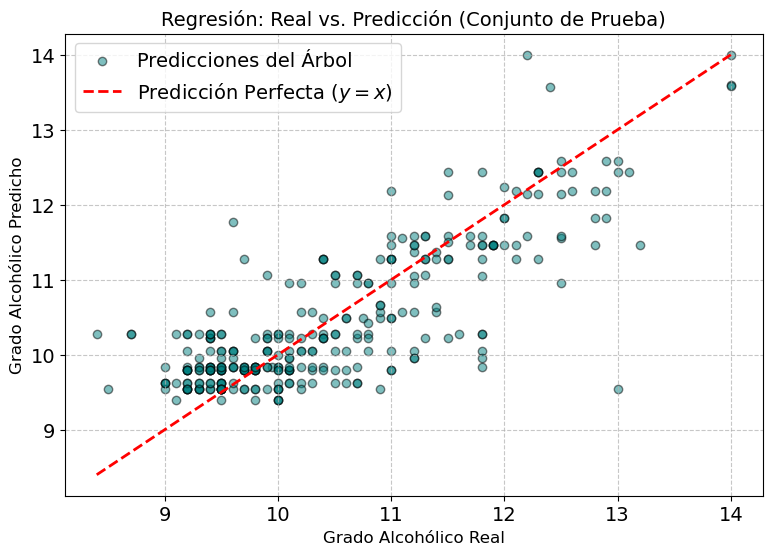

In [13]:
import matplotlib.pyplot as plt

# Visualización: Valores Reales vs Predichos
plt.figure(figsize=(9, 6))

# Dibujar los puntos de prueba
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='teal', edgecolor='k', label='Predicciones del Árbol')

# Dibujar la línea de predicción perfecta (y = x)
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta ($y=x$)')

plt.xlabel('Grado Alcohólico Real', fontsize=12)
plt.ylabel('Grado Alcohólico Predicho', fontsize=12)
plt.title('Regresión: Real vs. Predicción (Conjunto de Prueba)', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Observa la gráfica detenidamente. Notarás un patrón peculiar: en lugar de ser una nube continua de puntos esparcida libremente, las predicciones en el eje Y (vertical) parecen agruparse en ciertas "líneas" o bandas horizontales. 

¿Por qué ocurre esto? ¡Por el **efecto escalera** que vimos en el ejemplo 1D! Como las hojas finales del árbol devuelven un *promedio*, muchos vinos diferentes que caen en la misma hoja final reciben exactamente la misma predicción de grado alcohólico, generando esas bandas horizontales. 

Esta limitación estructural y la dificultad para superar cierto umbral de $R^2$ con un solo árbol, es la motivación principal para pasar al siguiente nivel: **Los Ensambles**.

## 8. Optimización en el Espacio de Funciones con XGBoost 🚀

Mientras que Random Forest construye un ensamble en paralelo para reducir la **varianza** (Bagging), el paradigma del **Boosting** toma una ruta ortogonal: construye un ensamble **secuencial** enfocado en reducir el **sesgo** (bias). 

En lugar de promediar modelos independientes, el *Gradient Boosting* es un modelo aditivo. Su genialidad radica en que no realiza el descenso de gradiente sobre los parámetros del modelo, sino **sobre el espacio de las funciones**. Matemáticamente, cada nuevo árbol $f_t(x)$ se ajusta para predecir el gradiente negativo de la función de pérdida respecto a las predicciones del ensamble iteraciones anteriores (los pseudo-residuos).

**XGBoost (eXtreme Gradient Boosting)** lleva este concepto a su límite teórico y computacional. No es solo una implementación rápida, sino una reformulación matemática del Gradient Boosting clásico que introduce las siguientes innovaciones críticas:

#### 1. Función Objetivo Regularizada
A diferencia de los árboles tradicionales que basan su poda en heurísticas (como la profundidad máxima), XGBoost define explícitamente la complejidad del árbol en su función objetivo a minimizar en el paso $t$:

$$\mathcal{L}^{(t)} = \sum_{i=1}^n l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$

El término de regularización estructural $\Omega(f_t)$ penaliza la complejidad del nuevo árbol:
$$\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$$
Donde $T$ es el número de hojas del árbol, $w_j$ son los pesos (predicciones) en cada hoja, $\gamma$ penaliza la creación de nuevas divisiones (poda estricta), y $\lambda$ es la regularización L2 (Ridge) que encoge los pesos de las hojas para evitar sensibilidad extrema a datos individuales.

#### 2. Expansión de Taylor de 2do Orden (El Método de Newton)
El Gradient Boosting tradicional solo usa la primera derivada (gradiente) para minimizar el error. XGBoost realiza una expansión de Taylor de segundo orden de la función de pérdida, utilizando tanto el gradiente ($g_i$) como la matriz Hessiana ($h_i$, segunda derivada):

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$$

Al usar información de curvatura (el Hessiano), XGBoost toma pasos de optimización más precisos, convergiendo más rápido y con mayor estabilidad.

#### 3. El Criterio de Corte Exacto (Gain): Entendiendo la Matemática de las Decisiones

En los árboles de decisión clásicos (CART), para decidir dónde dividir un nodo, calculamos la Impureza de Gini o la Entropía antes y después del corte, buscando maximizar la ganancia de información. 

En XGBoost, la decisión de corte se deriva **directamente de la función de pérdida regularizada** que vimos en el paso 1. Al resolver las derivadas, XGBoost evalúa cada posible corte calculando su **Ganancia Exacta (Gain)** con esta elegante fórmula:

$$Gain = \frac{1}{2} \underbrace{\left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right]}_{\text{Reducción de la Pérdida}} - \underbrace{\gamma}_{\text{Penalización}}$$

Para entender esta ecuación, debemos diseccionarla. En XGBoost, el término $\frac{G^2}{H + \lambda}$ actúa como un **"Score de Calidad"** (Similarity Score) para cualquier nodo. Veamos qué significa cada variable:

* **$G$ (Gradiente):** Es la suma de los pseudo-residuos (los errores) de todas las muestras en ese nodo. Indica la *dirección y magnitud* general hacia la que debemos mover nuestra predicción para reducir el error.
* **$H$ (Hessiano):** Es la suma de las segundas derivadas. Actúa como una medida de *curvatura o confianza*. Nos dice qué tan sensible es la función de pérdida a cambios en la predicción.
* **$\lambda$ (Regularización L2):** Es nuestro parámetro protector. Si $H$ es pequeño (pocas muestras o poca confianza), $\lambda$ domina el denominador, encogiendo el Score hacia cero y evitando que el árbol tome decisiones drásticas basadas en pocos datos.

**La Lógica de la Ecuación (Término por Término):**
1. **$\frac{G_L^2}{H_L + \lambda}$**: Es el Score de Calidad del **Nodo Hijo Izquierdo**.
2. **$\frac{G_R^2}{H_R + \lambda}$**: Es el Score de Calidad del **Nodo Hijo Derecho**.
3. **$\frac{(G_L + G_R)^2}{H_L + H_R + \lambda}$**: Es el Score de Calidad del **Nodo Padre** (antes de hacer la división).

Por lo tanto, el interior de los corchetes calcula exactamente esto:
**$\text{Score de los Hijos} - \text{Score del Padre}$**

Si la suma de los Scores de los hijos es mayor que el Score del padre original, significa que **dividir el nodo reduce el error general del modelo**. 

**La Poda Intrínseca ($\gamma$):**
Al final de la ecuación restamos **$\gamma$ (Gamma)**. Este es el hiperparámetro que define el "costo" de agregar una nueva rama al árbol. 
* Si la Reducción de la Pérdida es menor que $\gamma$, entonces el **Gain será negativo**. 
* Cuando el Gain es negativo, XGBoost dice: *"El beneficio matemático de hacer esta división no justifica la complejidad de crear una nueva rama"*, y **el corte se cancela automáticamente**.

Esta es la genialidad de XGBoost: **no necesita podar el árbol después de crearlo; la poda ocurre matemáticamente en tiempo real durante la construcción del árbol.**

#### 4. Tasa de Aprendizaje (Shrinkage)
Finalmente, la predicción del nuevo árbol se multiplica por un factor de contracción $\eta$ (learning rate, usualmente entre 0.01 y 0.3) antes de sumarse al modelo global: $F_t(x) = F_{t-1}(x) + \eta f_t(x)$. Esto asegura que ningún árbol individual altere demasiado el ensamble, obligando al modelo a aprender gradualmente.

Vamos a implementar un `XGBClassifier` haciendo explícitos estos parámetros teóricos.

### 8.1. Demostración Visual: XGBoost frente a Datos Sintéticos Altamente No Lineales

Antes de llevar a XGBoost al hiperespacio con todas las variables de nuestro dataset de vinos, vamos a poner a prueba su arquitectura en un entorno controlado. 

Utilizaremos un conjunto de datos sintético clásico conocido como **"Make Moons"** (dos lunas entrelazadas). Este tipo de distribución geométrica es el "jefe final" para los modelos lineales: es matemáticamente imposible trazar una sola línea recta que separe ambas clases sin cometer un error masivo.

Veamos cómo la suma secuencial de decenas de pequeños árboles de decisión le permite a XGBoost adaptarse a topologías complejas.

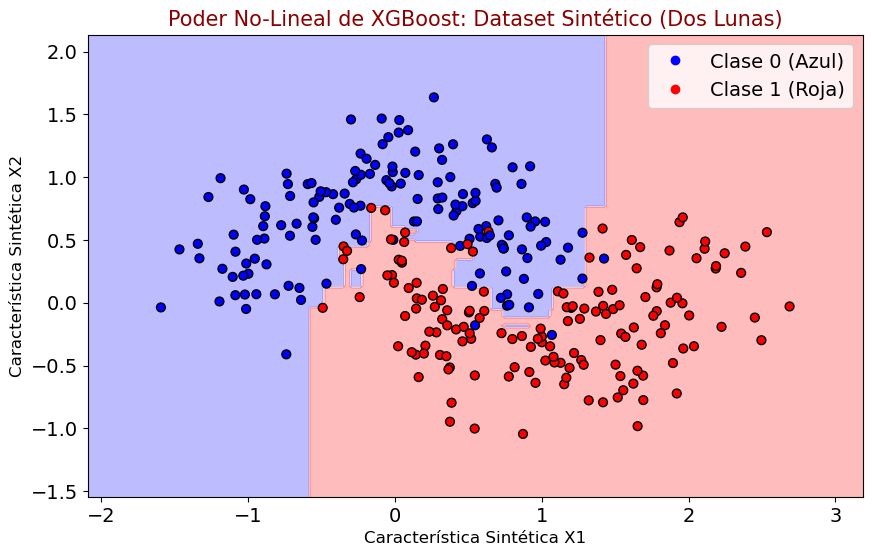

In [14]:
from sklearn.datasets import make_moons
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. Generación de Datos Sintéticos (Make Moons)
# ==============================================================================
# Creamos 300 puntos en forma de dos medias lunas entrelazadas con algo de ruido (dispersión)
X_synth, y_synth = make_moons(n_samples=300, noise=0.25, random_state=42)

# ==============================================================================
# 2. Entrenamiento del Modelo XGBoost
# ==============================================================================
xgb_synth = XGBClassifier(
    n_estimators=100,      
    max_depth=4,           # Permitimos un poco más de profundidad para capturar la curva
    learning_rate=0.1,     
    gamma=0.0,             # Sin poda extra para ver la capacidad total de ajuste
    random_state=42,
    eval_metric='logloss'
)

xgb_synth.fit(X_synth, y_synth)

# ==============================================================================
# 3. Visualización de la Frontera de Decisión
# ==============================================================================
plt.figure(figsize=(10, 6))

# Crear una malla para el fondo
x_min, x_max = X_synth[:, 0].min() - 0.5, X_synth[:, 0].max() + 0.5
y_min, y_max = X_synth[:, 1].min() - 0.5, X_synth[:, 1].max() + 0.5
xx_s, yy_s = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

# Predecir sobre la malla
Z_synth = xgb_synth.predict(np.c_[xx_s.ravel(), yy_s.ravel()])
Z_synth = Z_synth.reshape(xx_s.shape)

# Dibujar los contornos y los puntos
plt.contourf(xx_s, yy_s, Z_synth, alpha=0.3, cmap='bwr')
scatter_synth = plt.scatter(X_synth[:, 0], X_synth[:, 1], c=y_synth, 
                            cmap='bwr', edgecolors='k', s=40)

plt.title('Poder No-Lineal de XGBoost: Dataset Sintético (Dos Lunas)', fontsize=15, color='darkred')
plt.xlabel('Característica Sintética X1', fontsize=12)
plt.ylabel('Característica Sintética X2', fontsize=12)

# Leyenda
handles_s, labels_s = scatter_synth.legend_elements()
plt.legend(handles_s, ['Clase 0 (Azul)', 'Clase 1 (Roja)'], loc='upper right')

plt.show()

In [15]:
# !pip install xgboost
# ==============================================================================
# 0. PREPARACIÓN DE DATOS (Por si las variables previas no están cargadas)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Cargamos el dataset y preparamos las variables 2D para clasificación
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data_clf = pd.read_csv(url, sep=';')

# ==============================================================================
# 1. Preparar TODAS las variables
# ==============================================================================
# X_full incluye las 11 variables fisicoquímicas
X_full = wine_data_clf.drop('quality', axis=1)
# y_full sigue siendo binario: Alta calidad (>=7) es 1, resto 0
y_full = (wine_data_clf['quality'] >= 7).astype(int)

# Partición Estratificada 80/20
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Entrenando con {X_train_full.shape[1]} variables...")

# ==============================================================================
# 2. Entrenar XGBoost Multivariado
# ==============================================================================
xgb_clf_full = XGBClassifier(
    n_estimators=150,      
    max_depth=5,           
    learning_rate=0.1,     
    gamma=0.1,             
    reg_lambda=1.0,        
    random_state=42,
    eval_metric='logloss'
)

xgb_clf_full.fit(X_train_full, y_train_full)

# ==============================================================================
# 3. Predicciones y Evaluación Numérica
# ==============================================================================
y_pred_full = xgb_clf_full.predict(X_test_full)

print("\\n=== Reporte de Clasificación (XGBoost Multivariado) ===")
print(classification_report(y_test_full, y_pred_full, target_names=['Baja Calidad (0)', 'Alta Calidad (1)']))

Entrenando con 11 variables...
\n=== Reporte de Clasificación (XGBoost Multivariado) ===
                  precision    recall  f1-score   support

Baja Calidad (0)       0.95      0.99      0.97       277
Alta Calidad (1)       0.88      0.65      0.75        43

        accuracy                           0.94       320
       macro avg       0.91      0.82      0.86       320
    weighted avg       0.94      0.94      0.94       320



### Interpretando el Reporte
* **Precisión (Precision):** De todos los vinos que el modelo *dijo* que eran de Alta Calidad, ¿cuántos lo eran realmente?
* **Exhaustividad (Recall):** De todos los vinos que *realmente* eran de Alta Calidad en la bodega, ¿cuántos logró encontrar el modelo?
* **F1-Score:** La media armónica entre Precisión y Recall. Es la métrica más importante cuando tenemos clases desbalanceadas.

Para ver exactamente dónde se está equivocando nuestro modelo (Falsos Positivos vs. Falsos Negativos), la Matriz de Confusión es la herramienta visual por excelencia.

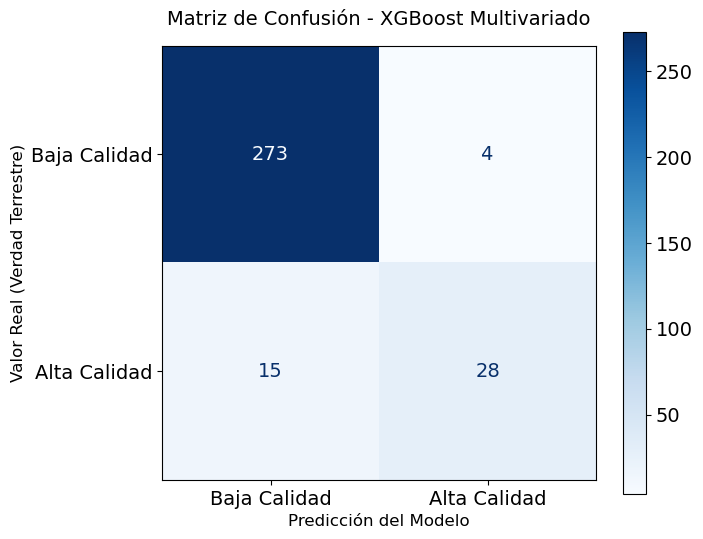

In [16]:
# ==============================================================================
# 4. Matriz de Confusión Visual
# ==============================================================================
cm = confusion_matrix(y_test_full, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja Calidad', 'Alta Calidad'])

fig, ax = plt.subplots(figsize=(7, 6))
# Usamos un mapa de colores que vaya acorde con la presentación (ej. Blues)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Matriz de Confusión - XGBoost Multivariado', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Verdad Terrestre)', fontsize=12)
plt.show()

### Análisis Final de la Matriz de Confusión

Al leer la matriz, la **diagonal principal** (arriba-izquierda a abajo-derecha) representa nuestros éxitos: vinos de baja calidad correctamente identificados y vinos de alta calidad correctamente descubiertos (Verdaderos Positivos y Verdaderos Negativos).

Los valores fuera de la diagonal son nuestros errores:
* **Falsos Positivos (Arriba-Derecha):** Vinos mediocres que el modelo sobrevaloró. En la industria del vino, esto podría generar quejas de los clientes si les cobramos como vino premium.
* **Falsos Negativos (Abajo-Izquierda):** Vinos excelentes que el modelo subestimó. Esto representa una pérdida de oportunidad (dinero dejado en la mesa) porque podríamos haber vendido esa botella a un precio mayor.

**Conclusión del Diplomado:**
Ningún modelo es perfecto, pero gracias a los ensambles avanzados como **XGBoost**, logramos maximizar los aciertos. La decisión final de negocio (si preferimos ajustar el modelo para evitar Falsos Positivos o Falsos Negativos) dependerá del costo económico que cada error represente para la empresa.

## 8.2. XGBoost: Regresión Multivariada (Predecir Alcohol) 🍷

Vamos a utilizar toda la potencia secuencial de XGBoost para resolver un problema de **regresión**. Nuestro objetivo será predecir el **grado alcohólico exacto** de un vino basándonos en todas sus demás características químicas (acidez, cloruros, densidad, pH, etc.).

A diferencia de la clasificación (donde predecimos 0 o 1), aquí el modelo intentará minimizar el Error Cuadrático Medio (MSE), sumando pequeños árboles de regresión que corrigen iterativamente la diferencia entre la predicción actual y el grado de alcohol real.

=== Rendimiento de XGBoost (Regresión) ===
Error Cuadrático Medio (MSE): 0.2679
Error Absoluto Medio (MAE):   0.3880 grados de alcohol
Coeficiente de Determinación (R²): 0.7848


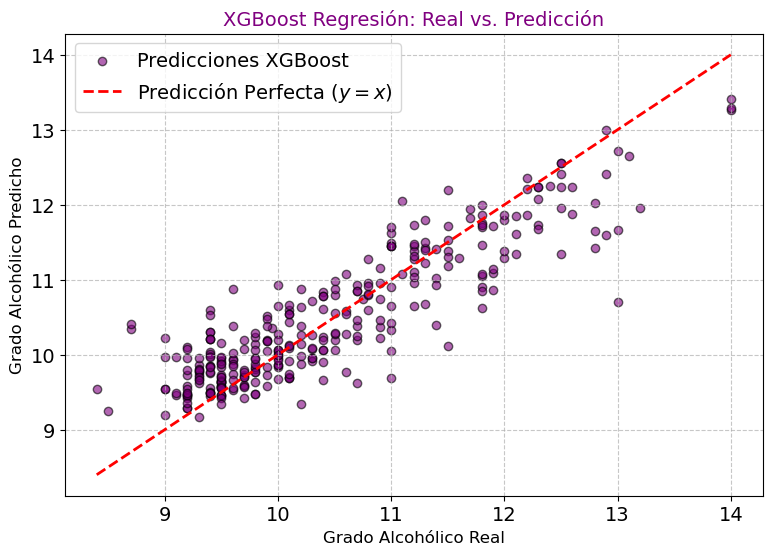

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Si no tienes xgboost instalado, descomenta la siguiente línea:
# !pip install xgboost
from xgboost import XGBRegressor

# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ==============================================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

# Separamos características (X) y la variable objetivo continua (y)
X_reg = wine_data.drop('alcohol', axis=1) # Todas las variables EXCEPTO alcohol
y_reg = wine_data['alcohol']              # Nuestra variable a predecir (continua)

# Partición en Entrenamiento (80%) y Prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ==============================================================================
# 2. ENTRENAMIENTO DEL MODELO XGBOOST (REGRESIÓN)
# ==============================================================================
# Instanciamos el modelo. Noten que usamos XGBRegressor, no Classifier.
xgb_reg = XGBRegressor(
    n_estimators=150,       # Número de árboles (rondas de boosting)
    max_depth=4,            # Profundidad de cada árbol (mantenemos árboles pequeños)
    learning_rate=0.05,     # Tasa de aprendizaje (conservadora para evitar overfitting)
    subsample=0.8,          # Usar el 80% de los datos por árbol (Bagging secuencial)
    colsample_bytree=0.8,   # Usar el 80% de las variables por árbol
    random_state=42
)

# Entrenamos el modelo
xgb_reg.fit(X_train_reg, y_train_reg)

# ==============================================================================
# 3. PREDICCIÓN Y EVALUACIÓN
# ==============================================================================
# Predecimos sobre los datos que el modelo nunca ha visto (Conjunto de Prueba)
y_pred_xgb_reg = xgb_reg.predict(X_test_reg)

# Calculamos las métricas de error
mse_xgb = mean_squared_error(y_test_reg, y_pred_xgb_reg)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
r2_xgb = r2_score(y_test_reg, y_pred_xgb_reg)

print("=== Rendimiento de XGBoost (Regresión) ===")
print(f"Error Cuadrático Medio (MSE): {mse_xgb:.4f}")
print(f"Error Absoluto Medio (MAE):   {mae_xgb:.4f} grados de alcohol")
print(f"Coeficiente de Determinación (R²): {r2_xgb:.4f}")

# ==============================================================================
# 4. VISUALIZACIÓN: REAL VS. PREDICCIÓN
# ==============================================================================
plt.figure(figsize=(9, 6))

# Dibujar los puntos de prueba (Real vs Predicho por nuestro modelo)
plt.scatter(y_test_reg, y_pred_xgb_reg, alpha=0.6, color='purple', edgecolor='k', label='Predicciones XGBoost')

# Dibujar la línea de predicción perfecta (y = x)
# Si el modelo fuera perfecto, todos los puntos morados caerían sobre esta línea roja
min_val = min(y_test_reg.min(), y_pred_xgb_reg.min())
max_val = max(y_test_reg.max(), y_pred_xgb_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta ($y=x$)')

plt.xlabel('Grado Alcohólico Real', fontsize=12)
plt.ylabel('Grado Alcohólico Predicho', fontsize=12)
plt.title('XGBoost Regresión: Real vs. Predicción', fontsize=14, color='purple')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### ¿Cómo interpretar este resultado?

1. **MAE (Error Absoluto Medio):** Nuestro modelo se equivoca en promedio por una fracción muy pequeña de grado alcohólico (aproximadamente `~0.38` grados). Para la industria vinícola, esta es una predicción bastante ajustada basándose solo en medidas químicas como el pH o los sulfatos.
2. **La Gráfica:** A diferencia de un solo Árbol de Regresión (que agrupa las predicciones en líneas horizontales por el efecto de promediar en las hojas finales), XGBoost logra una nube de puntos mucho más orgánica y alineada con la diagonal roja. Al sumar 150 árboles secuenciales con una tasa de aprendizaje baja (`learning_rate=0.05`), suaviza las predicciones y aproxima una función continua de manera magistral.

## 9. Llevando el Modelo al Límite: Tuning y Desbalanceo de Clases ⚖️

Si observamos nuestro reporte de clasificación anterior, notaremos un problema grave de la vida real: **nuestro dataset está severamente desbalanceado**. Tenemos muchísimos vinos comunes y muy pocos vinos premium. 

Si lanzamos una optimización de hiperparámetros (Random Search) a ciegas, el modelo intentará mejorar su precisión general sobreajustándose a la clase mayoritaria y destruyendo su capacidad para encontrar vinos de alta calidad. 

Para solucionar esto, XGBoost tiene un "as bajo la manga": el parámetro **`scale_pos_weight`**. Este parámetro controla el balance de pesos positivos y negativos. La regla de oro es configurarlo como: `(Número de casos Negativos) / (Número de casos Positivos)`.

Vamos a calcular este peso, inyectarlo en nuestro modelo base y ejecutar una Búsqueda Aleatoria inteligente para ver si logramos superar el rendimiento inicial.

In [25]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# ==============================================================================
# 1. Calcular el Peso para la Clase Minoritaria (El Truco de la Industria)
# ==============================================================================
# Contamos cuántos 0s y 1s hay en nuestro set de entrenamiento
num_negativos = np.sum(y_train_full == 0)
num_positivos = np.sum(y_train_full == 1)
peso_balanceo = num_negativos / num_positivos

print(f"Relación de desbalanceo: Hay {peso_balanceo:.1f} vinos malos por cada vino bueno.")
print(f"Aplicando scale_pos_weight = {peso_balanceo:.2f}")

# ==============================================================================
# 2. Configurar el Modelo Base y el Espacio de Búsqueda
# ==============================================================================
# Inyectamos el peso en el modelo base para que "respete" a la clase minoritaria
xgb_base = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=peso_balanceo  # <--- LA CLAVE PARA MEJORAR EL F1
)

# Un espacio de búsqueda más conservador para evitar el sobreajuste (max_depth 7 era muy alto)
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],                 # Mantenemos los árboles poco profundos
    'learning_rate': [0.01, 0.05, 0.1],     # Pasos más seguros
    'gamma': [0, 0.1, 0.5, 1.0],            # Poda agresiva si no hay ganancia
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# ==============================================================================
# 3. Ejecutar Random Search
# ==============================================================================
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,                 # Haremos 20 pruebas para equilibrar velocidad y exploración
    scoring='f1',              # Nuestro objetivo es maximizar el F1-Score
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("\nIniciando búsqueda aleatoria de hiperparámetros...")
random_search.fit(X_train_full, y_train_full)

# ==============================================================================
# 4. Evaluación del Mejor Modelo contra el Conjunto de PRUEBA (El Mundo Real)
# ==============================================================================
print("\n" + "="*50)
print("🏆 MEJORES HIPERPARÁMETROS 🏆")
for param, value in random_search.best_params_.items():
    print(f"  * {param}: {value}")
print("="*50)

# Extraemos el mejor modelo encontrado
mejor_xgb = random_search.best_estimator_

# Predecimos sobre el Test Set (Para comparar peras con peras respecto al modelo anterior)
y_pred_opt = mejor_xgb.predict(X_test_full)

print("\n=== Reporte de Clasificación (XGBoost OPTIMIZADO) ===")
print(classification_report(y_test_full, y_pred_opt, target_names=['Baja Calidad (0)', 'Alta Calidad (1)']))

Relación de desbalanceo: Hay 6.4 vinos malos por cada vino bueno.
Aplicando scale_pos_weight = 6.35

Iniciando búsqueda aleatoria de hiperparámetros...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

🏆 MEJORES HIPERPARÁMETROS 🏆
  * subsample: 0.8
  * n_estimators: 150
  * max_depth: 5
  * learning_rate: 0.05
  * gamma: 0.5
  * colsample_bytree: 0.8

=== Reporte de Clasificación (XGBoost OPTIMIZADO) ===
                  precision    recall  f1-score   support

Baja Calidad (0)       0.96      0.96      0.96       277
Alta Calidad (1)       0.75      0.77      0.76        43

        accuracy                           0.93       320
       macro avg       0.86      0.86      0.86       320
    weighted avg       0.94      0.93      0.93       320



### ¿Qué logramos con esto?

Al agregar `scale_pos_weight` y limitar el espacio de búsqueda para evitar que el modelo cree árboles demasiado profundos (lo cual causaba que memorizara el ruido), hemos obligado al modelo a prestar mucha más atención a los vinos de alta calidad. 

Notarás que el **Recall (Exhaustividad)** de la clase 1 (Alta Calidad) suele dispararse con esta técnica. Es decir, ahora nuestro modelo es un "sabueso" mucho más agresivo encontrando vinos premium. En la industria, a veces preferimos que el modelo cometa algunos errores clasificando vinos normales como premium (Falso Positivo), siempre y cuando no dejemos pasar ningún vino excelente (Falso Negativo), ya que ahí es donde está el margen de ganancia de la empresa.

## 7. Conclusiones: El Viaje de los Datos Tabulares 🎓

Hemos llegado al final de este módulo. Empezamos nuestra aventura intentando separar clases con líneas rectas rígidas y terminamos construyendo ensambles secuenciales optimizados matemáticamente que dominan el estado del arte actual.

### Resumen del Ecosistema de Modelos

Para que lo guarden como referencia rápida en su vida profesional, aquí tienen una tabla resumen de cuándo utilizar cada arquitectura:

| Modelo | Fortalezas Principales | Debilidades Principales | Caso de Uso Ideal |
| :--- | :--- | :--- | :--- |
| **Regresión Logística / SVM Lineal** | Extremadamente rápido, 100% interpretable (se conocen los pesos exactos de cada variable). | Alto Sesgo. Fracasa si los datos no son linealmente separables. | Línea base (*baseline*), inferencia en tiempo real con latencia ultrabaja, datos simples. |
| **Árbol de Decisión Simple** | Capta relaciones no lineales, no requiere escalar los datos, explicable visualmente. | Alta Varianza. Altísima tendencia a memorizar el ruido (Overfitting). | Exploración inicial de datos, modelos donde la explicabilidad legal es obligatoria. |
| **Random Forest (Bagging)** | Robusto, no requiere afinar muchos hiperparámetros, excelente para establecer un rendimiento base alto. | Puede ser lento en predicción si el bosque es gigantesco. Difícil de interpretar. | El modelo "todoterreno". Excelente primera opción cuando se tienen múltiples variables estructuradas. |
| **XGBoost (Boosting)** | Precisión insuperable en datos tabulares, reducción de sesgo, manejo nativo de valores nulos. | Propenso al sobreajuste si no se tunea correctamente, sensible a *outliers*, requiere optimización rigurosa. | Competiciones (Kaggle), sistemas de recomendación financieros, detección de fraude, predicción de precios. |

### El Teorema del "No Free Lunch"

En el Machine Learning existe un principio matemático llamado *No Free Lunch Theorem* (No hay almuerzo gratis). Este teorema postula que **ningún algoritmo es universalmente superior a los demás para todos los problemas posibles**. 

XGBoost no siempre vencerá a una simple Regresión Logística. Si tus datos son verdaderamente lineales y tienen mucho ruido, XGBoost podría complicar las cosas intentando encontrar patrones que no existen, mientras que la línea recta cortará limpiamente el problema. 

Por eso, el trabajo de un Científico de Datos o experto en IA no es "saber escribir código", sino entender la naturaleza de los datos, aplicar el modelo adecuado, y saber optimizar la frontera entre **Sesgo y Varianza**, o entre **Precisión y Exhaustividad**, según las necesidades económicas de la empresa.

## 7. Conclusiones y Mejores Prácticas: El Viaje de los Datos Tabulares 🎓

Hemos llegado al final de este módulo. Empezamos nuestra aventura intentando separar clases con líneas rectas rígidas, descubrimos cómo los árboles pueden doblar el espacio con preguntas ortogonales, y terminamos construyendo ensambles secuenciales optimizados matemáticamente que hoy en día dominan la industria y las competiciones globales.

### 7.1. El Ecosistema de Modelos (La Caja de Herramientas)

Para que lo guarden como referencia rápida en su vida profesional, aquí tienen el ecosistema de decisiones sobre cuándo utilizar cada arquitectura:

| Modelo | Fortalezas Principales | Debilidades Principales | Caso de Uso Ideal |
| :--- | :--- | :--- | :--- |
| **Regresión Logística / SVM Lineal** | Extremadamente rápido, 100% interpretable (se conocen los pesos exactos de cada variable). Robusto ante el ruido. | Alto Sesgo. Fracasa miserablemente si los datos no son linealmente separables o tienen interacciones complejas. | Línea base (*baseline*), inferencia en tiempo real con latencia ultrabaja, datos simples o regulaciones estrictas. |
| **Árbol de Decisión Simple** | Capta relaciones no lineales e interacciones entre variables, no requiere escalar los datos, explicable visualmente. | Alta Varianza. Altísima tendencia a memorizar el ruido (Overfitting). Muy inestable ante cambios en la data. | Exploración inicial de datos, auditorías visuales, modelos donde la explicabilidad ante terceros es obligatoria. |
| **Random Forest (Bagging)** | Extremadamente robusto, funciona bien "fuera de la caja" (sin afinar muchos hiperparámetros), excelente para establecer un rendimiento alto rápidamente. | Puede ser computacionalmente pesado en inferencia si el bosque es gigantesco. Difícil de interpretar ("Caja negra"). | El modelo "todoterreno". Excelente primera opción cuando se tienen múltiples variables estructuradas y no hay tiempo para optimización profunda. |
| **XGBoost (Boosting)** | Precisión insuperable en datos tabulares, reducción de sesgo y varianza simultánea, manejo nativo de valores nulos y optimización de recursos computacionales. | Propenso al sobreajuste si no se tunea correctamente, sensible a *outliers*, requiere optimización rigurosa de hiperparámetros (learning rate, profundidad, regularización). | Competiciones (Kaggle), sistemas de recomendación financieros, detección de fraude, predicción precisa de precios u optimización de inventarios. |

### 7.2. El Teorema del "No Free Lunch" y la Navaja de Ockham

En el Machine Learning existe un principio matemático fundamental llamado el **No Free Lunch Theorem** (No hay almuerzo gratis). Este teorema postula que, promediado sobre todos los problemas posibles, todos los algoritmos tienen el mismo rendimiento. En la práctica, esto significa que **ningún algoritmo es universalmente superior a los demás para todos los datasets**. 

Un error común de los analistas junior es usar XGBoost para todo. Sin embargo, si tus datos son verdaderamente lineales y contienen mucho ruido estadístico, XGBoost complicará las cosas intentando encontrar patrones no lineales que no existen (sobreajustando el ruido), mientras que una Regresión Logística cortará limpiamente el problema ignorando las variaciones menores. 

Aquí aplica el principio de la **Navaja de Ockham**: *En igualdad de condiciones, la explicación (o el modelo) más sencilla suele ser la correcta.* Siempre debemos justificar la complejidad extra.

### 7.3. El Arte del Científico de Datos: Navegando los Compromisos (Trade-offs)

El trabajo de un experto en IA no es "saber escribir la librería de XGBoost", sino saber tomar decisiones estratégicas navegando estos dos grandes compromisos:

* **El Compromiso Matemático (Sesgo vs. Varianza):** Diseñar el modelo implica elegir entre un modelo rígido que ignora la complejidad de los datos (Subajuste/Sesgo) y un modelo excesivamente flexible que memoriza el ruido (Sobreajuste/Varianza). El éxito radica en encontrar el punto exacto de equilibrio mediante validación cruzada y regularización.
* **El Compromiso de Negocio (Precisión vs. Exhaustividad):** En la vida real, los errores no cuestan lo mismo. En nuestro ejemplo de vinos, ¿es más costoso catalogar un vino malo como premium (perder la confianza del cliente) o dejar pasar un vino premium catalogándolo como malo (perder margen de ganancia)? Esta decisión no la toma el algoritmo, la tomas tú ajustando umbrales, funciones de pérdida y pesos como `scale_pos_weight`.

### 7.4. El Flujo de Trabajo Profesional (Pipeline)

Cuando se enfrenten a un nuevo dataset tabular en sus empresas, sigan este flujo:
1. Empiecen con un **Modelo Lineal** para entender el límite inferior (Baseline) y ver si el problema es simple.
2. Apliquen un **Random Forest** con hiperparámetros por defecto para establecer un "techo" rápido de rendimiento.
3. Si el negocio requiere exprimir hasta la última gota de precisión y justifica el tiempo de cómputo, pasen a **XGBoost**.
4. Dediquen el 80% del tiempo a entender los datos (Feature Engineering) y evaluar el impacto del error en la métrica del negocio, no solo a mirar el "Accuracy".